# stimRemovalNull Sessions Analysis (ephax Quickstart Style)

This notebook loads recording sessions from `stimRemovalNull` directories and runs the same core analyses as `ephax_quickstart.ipynb`.


In [25]:
%matplotlib inline
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import RestingActivityDataset, PrepConfig, LayoutGridPlotter, DCTAnalyzer
from ephax.analyzers import IFRAnalyzer
from ephax.analyzers.ifr import IFRConfig
from ephax.analyzers.firing_distance import FiringDistanceAnalyzer
from ephax.analyzers.cofiring_temporal import CofiringTemporalAnalyzer, CofiringTemporalConfig
from ephax.metrics import (
    activity_state_kde_peak_frequencies,
    binned_kde_peak_summary,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    extract_activity_state_ifr,
)
from ephax.plotting import plot_activity_state_ifr_kde_histograms

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


## Configure Session Loading

Set `WELLS` and `DIVS` explicitly. For now `DIVS` can contain one DIV, but the same loading code supports multiple DIVs later.


In [26]:
WELLS = [0, 1, 2, 3, 4, 5]
DIVS = [21]
DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
DATA_FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

START_SEC = 0.0
END_SEC = 300.0
MIN_AMP = 0.0

TOP_START = 0
TOP_STOP = 300

V_AX = 0.8
V_EPH = 0.1

recording_specs = []
missing_paths = []
for div in DIVS:
    for well in WELLS:
        path = DATA_ROOT / f"well{well}" / DATA_FILENAME_TEMPLATE.format(div=int(div), well=int(well))
        if path.exists():
            recording_specs.append(
                {
                    "path": path,
                    "well": int(well),
                    "div": int(div),
                    "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
                    "culture_id": f"stimRemovalNull_well{int(well)}",
                }
            )
        else:
            missing_paths.append(path)

if not recording_specs:
    raise FileNotFoundError(f"No stimRemovalNull recordings found for WELLS={WELLS}, DIVS={DIVS}")

# Backward-compatible aliases for later labels and optional output filenames.
WELL = int(recording_specs[0]["well"])
DIV = int(recording_specs[0]["div"])
npz_path = recording_specs[0]["path"]
recording_labels = [f"well{spec['well']} DIV{spec['div']}" for spec in recording_specs]

pd.DataFrame(recording_specs)[["recording_id", "culture_id", "well", "div", "path"]]


,recording_id,culture_id,well,div,path
0,stimRemovalNull_well0_DIV21,stimRemovalNull_well0,0,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...
1,stimRemovalNull_well1_DIV21,stimRemovalNull_well1,1,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...
2,stimRemovalNull_well2_DIV21,stimRemovalNull_well2,2,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...
3,stimRemovalNull_well3_DIV21,stimRemovalNull_well3,3,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...
4,stimRemovalNull_well4_DIV21,stimRemovalNull_well4,4,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...
5,stimRemovalNull_well5_DIV21,stimRemovalNull_well5,5,21,/Users/danielrebbin/Documents/GitHub/ephax/eph...


In [27]:
file_info = []
recording_metadata = []
for spec in recording_specs:
    with np.load(spec["path"], allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0

    start_time = rec_t0 + START_SEC
    end_time = rec_t0 + END_SEC
    file_info.append((str(spec["path"]), start_time, end_time, int(spec["well"])))
    recording_metadata.append(
        {
            **spec,
            "source_path": str(spec["path"]),
            "start_time": float(start_time),
            "end_time": float(end_time),
            "sf_native": float(sf_native),
        }
    )

ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
rec = ds.recordings[0]

recording_summary_rows = []
for rec_idx, (rec_i, meta) in enumerate(zip(ds.recordings, recording_metadata)):
    in_window = (rec_i.spikes["time"] >= rec_i.start_time) & (rec_i.spikes["time"] <= rec_i.end_time)
    duration = float(rec_i.end_time - rec_i.start_time)
    n_spikes = int(np.sum(in_window))
    n_active_electrodes = int(np.unique(rec_i.spikes["electrode"][in_window]).size)
    recording_summary_rows.append(
        {
            "recording_idx": int(rec_idx),
            "recording_id": meta["recording_id"],
            "culture_id": meta["culture_id"],
            "well": int(meta["well"]),
            "div": int(meta["div"]),
            "duration_s": duration,
            "sf": float(rec_i.sf),
            "n_spikes": n_spikes,
            "n_active_electrodes": n_active_electrodes,
            "mean_spike_rate_hz": n_spikes / duration if duration > 0 else np.nan,
        }
    )

recording_summary = pd.DataFrame(recording_summary_rows)
aggregate_by_div = (
    recording_summary
    .groupby("div", as_index=False)
    .agg(
        n_recordings=("recording_idx", "count"),
        n_wells=("well", "nunique"),
        total_spikes=("n_spikes", "sum"),
        mean_spikes_per_recording=("n_spikes", "mean"),
        mean_active_electrodes=("n_active_electrodes", "mean"),
        mean_spike_rate_hz=("mean_spike_rate_hz", "mean"),
    )
)

print(f"Loaded {len(ds.recordings)} recordings across wells={WELLS} and DIVs={DIVS}")
if missing_paths:
    print(f"Missing requested files skipped: {len(missing_paths)}")
display(recording_summary.round(3))
display(aggregate_by_div.round(3))


Loaded 6 recordings across wells=[0, 1, 2, 3, 4, 5] and DIVs=[21]


,recording_idx,recording_id,culture_id,well,div,duration_s,sf,n_spikes,n_active_electrodes,mean_spike_rate_hz
0,0,stimRemovalNull_well0_DIV21,stimRemovalNull_well0,0,21,300.0,10000.0,48236,975,160.787
1,1,stimRemovalNull_well1_DIV21,stimRemovalNull_well1,1,21,300.0,10000.0,41209,953,137.363
2,2,stimRemovalNull_well2_DIV21,stimRemovalNull_well2,2,21,300.0,10000.0,30301,851,101.003
3,3,stimRemovalNull_well3_DIV21,stimRemovalNull_well3,3,21,300.0,10000.0,44479,958,148.263
4,4,stimRemovalNull_well4_DIV21,stimRemovalNull_well4,4,21,300.0,10000.0,53902,959,179.673
5,5,stimRemovalNull_well5_DIV21,stimRemovalNull_well5,5,21,300.0,10000.0,52233,973,174.110


,div,n_recordings,n_wells,total_spikes,mean_spikes_per_recording,mean_active_electrodes,mean_spike_rate_hz
0,21,6,6,270360,45060.0,944.833,150.2


## Layout Grid Visualizations

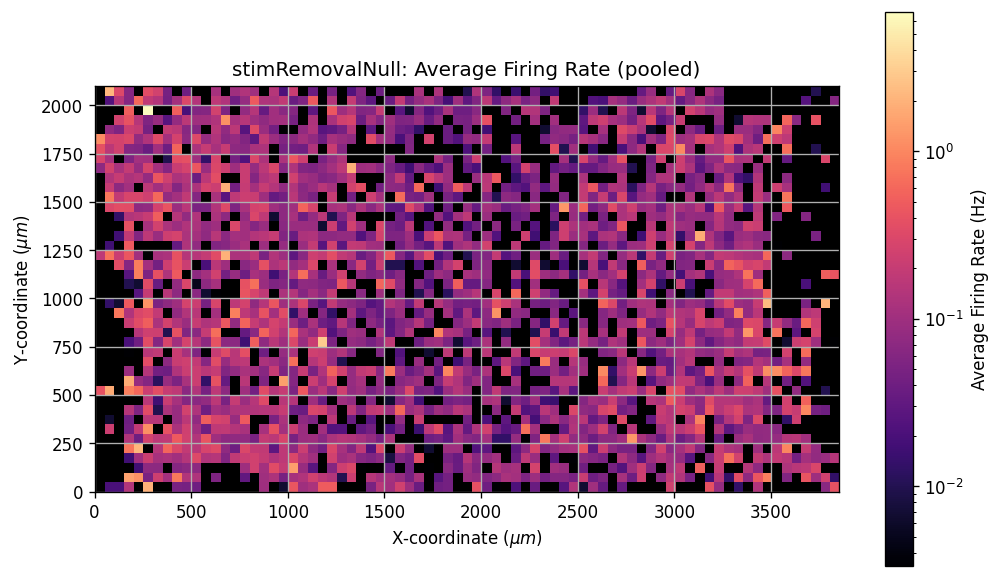

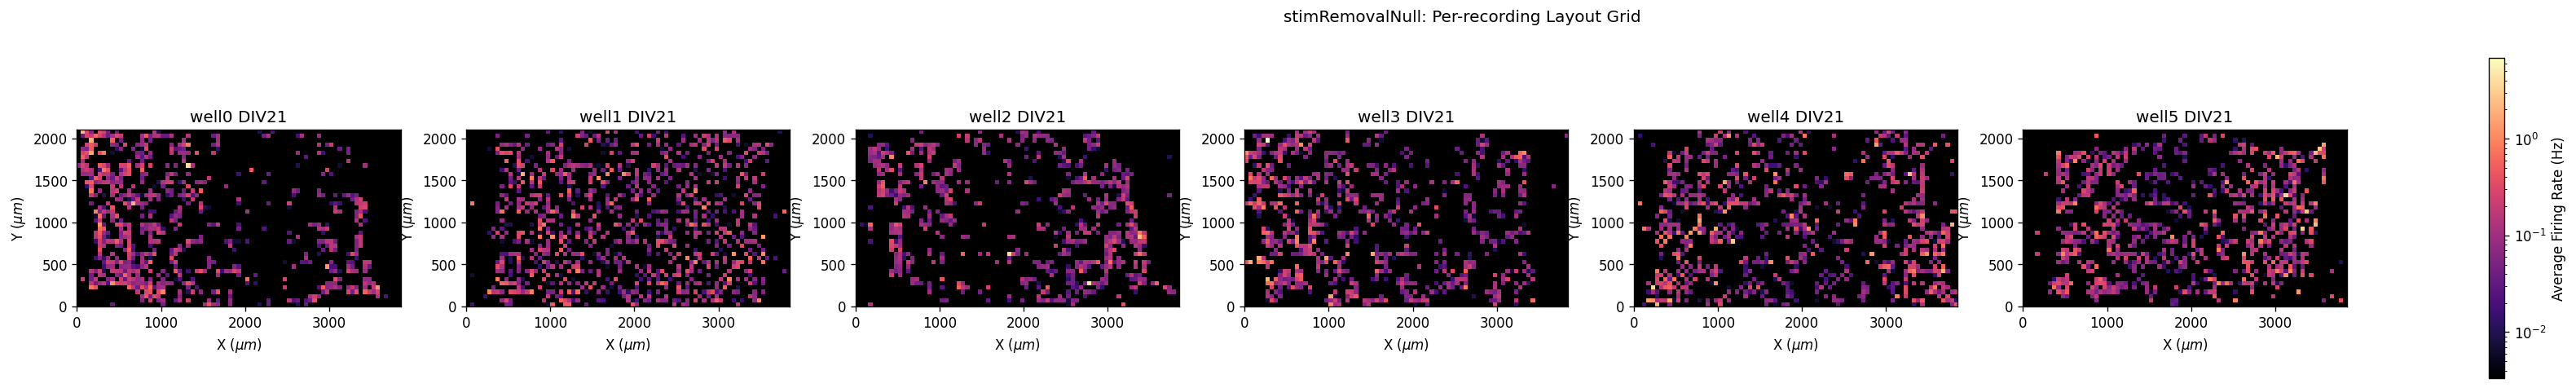

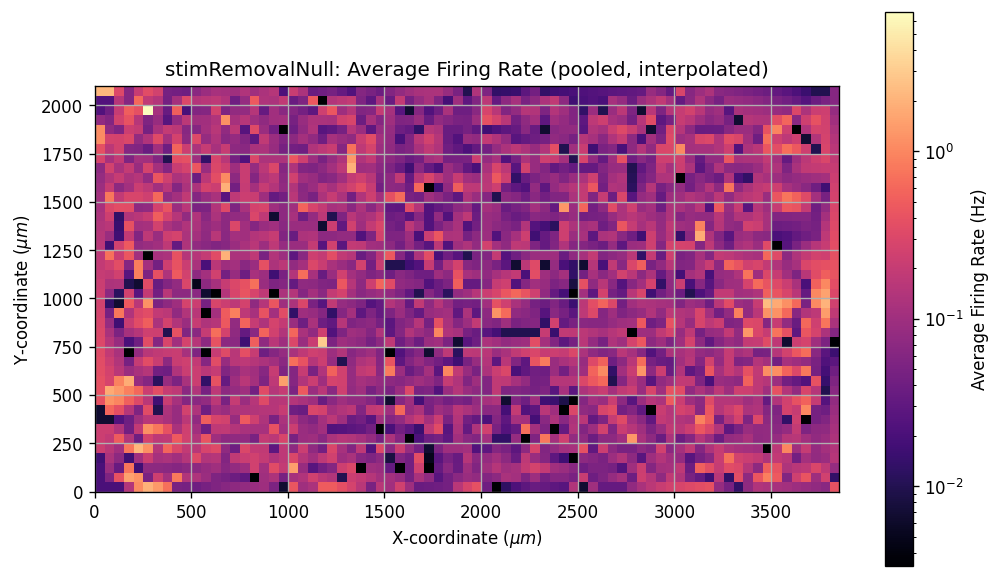

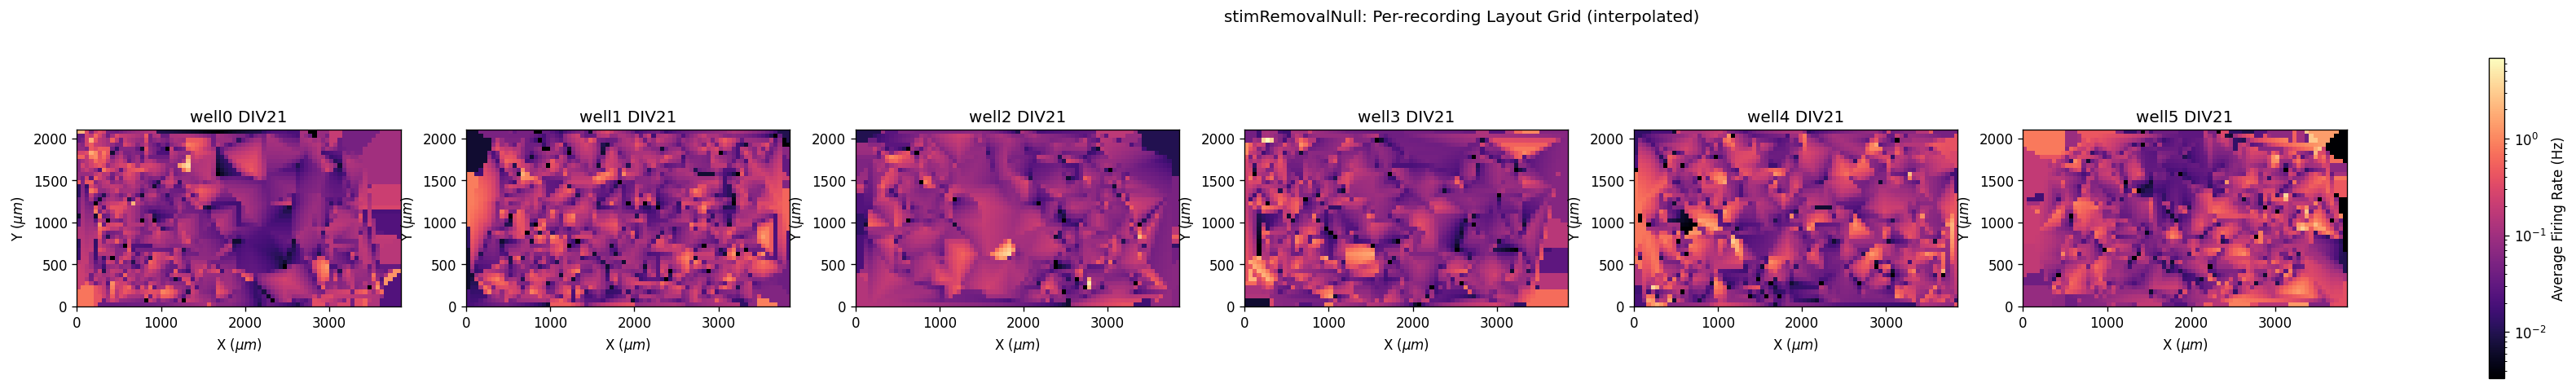

(<Figure size 3600x480 with 7 Axes>,
 array([[<Axes: title={'center': 'well0 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well1 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well2 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well3 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well4 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well5 DIV21'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>]],
       dtype=object))

In [28]:
lg = LayoutGridPlotter(ds)

# Without interpolation
lg.plot_grid_avghz_pooled(grid_size=50.0, interpolate=False, title="stimRemovalNull: Average Firing Rate (pooled)")
lg.plot_grid_avghz_panel(grid_size=50.0, ncols=6, interpolate=False, title="stimRemovalNull: Per-recording Layout Grid", recording_titles=recording_labels)

# With interpolation
lg.plot_grid_avghz_pooled(grid_size=50.0, interpolate=True, title="stimRemovalNull: Average Firing Rate (pooled, interpolated)")
lg.plot_grid_avghz_panel(grid_size=50.0, ncols=6, interpolate=True, title="stimRemovalNull: Per-recording Layout Grid (interpolated)", recording_titles=recording_labels)


## Select Reference Electrodes

In [29]:
top_stop = 1000
prep_cfg = PrepConfig(mode="top", top_start=0, top_stop=top_stop, verbose=False)
refs_per_recording = ds.select_ref_electrodes(prep_cfg)

for idx, refs in enumerate(refs_per_recording):
    preview = ", ".join(map(str, refs[:5])) + ("..." if refs.size > 5 else "")
    print(f"{recording_labels[idx]}: selected {refs.size} reference electrodes ({preview})")


well0 DIV21: selected 975 reference electrodes (26185, 20977, 15659, 12117, 3765...)
well1 DIV21: selected 953 reference electrodes (19619, 20117, 10541, 7881, 19231...)
well2 DIV21: selected 851 reference electrodes (3459, 7805, 10533, 10973, 7893...)
well3 DIV21: selected 958 reference electrodes (24875, 6831, 4197, 7269, 6825...)
well4 DIV21: selected 959 reference electrodes (2873, 9967, 20207, 25803, 1111...)
well5 DIV21: selected 973 reference electrodes (17119, 11849, 23741, 24183, 14053...)


## Activity-State IFR KDE Peaks for Distance Models

Extract raw ISI-derived IFR samples from high-activity non-burst and burst periods across the loaded recordings, then use their binned-KDE maxima above 30 Hz as fixed frequencies for downstream distance-model overlays.


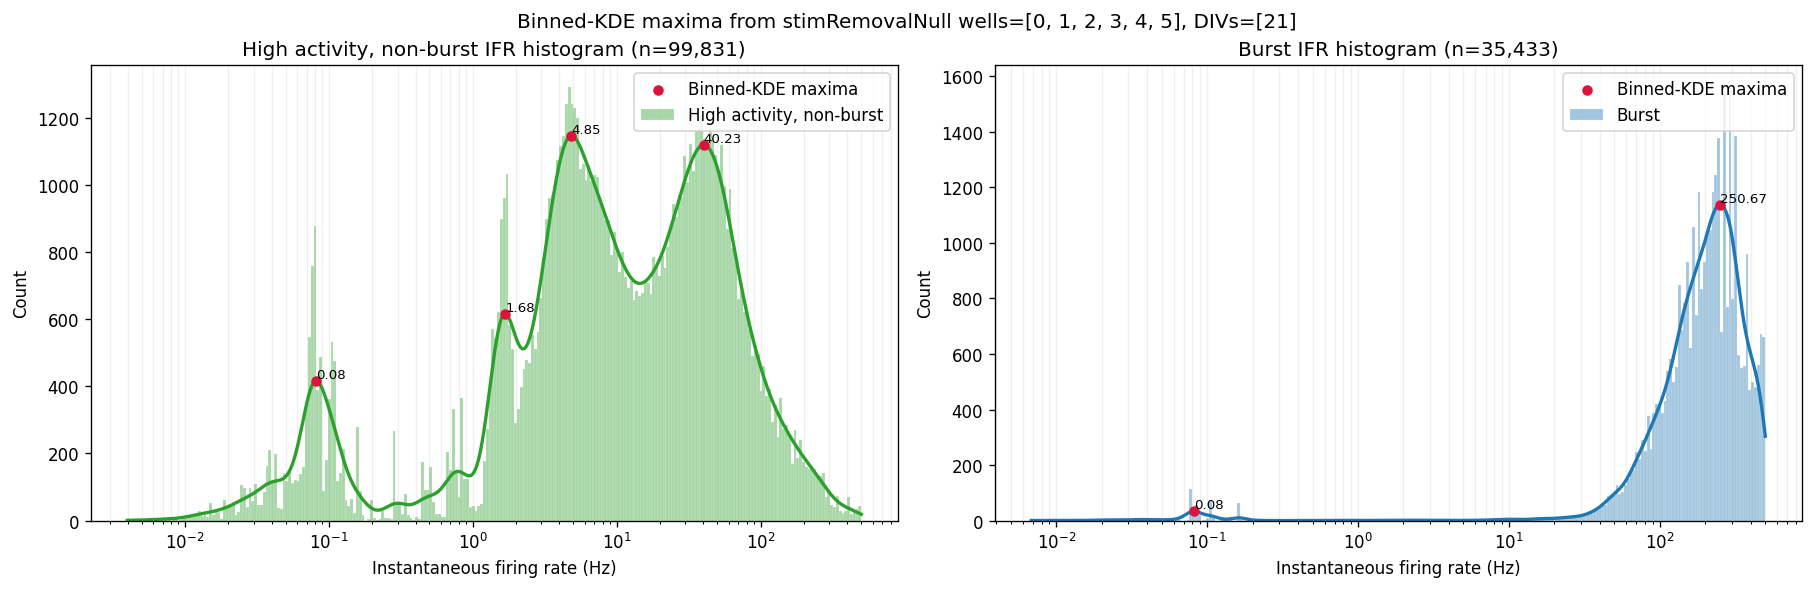

Fixed distance-model frequencies >30 Hz: [ 40.233 250.671]


,recording_idx,recording_id,well,div,n_refs,n_high_activity_periods,n_bursts,high_activity_threshold_hz,n_low_activity_ifr_samples,n_high_activity_ifr_samples,n_burst_ifr_samples
0,0,stimRemovalNull_well0_DIV21,0,21,975,46,46,0.177,26254,14775,6232
1,1,stimRemovalNull_well1_DIV21,1,21,953,47,57,0.154,19788,14979,5489
2,2,stimRemovalNull_well2_DIV21,2,21,851,40,41,0.140,19238,6013,4199
3,3,stimRemovalNull_well3_DIV21,3,21,958,43,50,0.131,18663,19170,5688
4,4,stimRemovalNull_well4_DIV21,4,21,959,56,79,0.196,21530,24759,6654
5,5,stimRemovalNull_well5_DIV21,5,21,973,58,60,0.197,23954,20135,7171


,period,source,peak_hz,peak_count,used_for_distance_model
0,burst,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",250.671,1136.793,True
1,burst,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",0.082,33.043,False
2,high_activity,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",4.850,1147.020,False
3,high_activity,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",40.233,1119.591,True
4,high_activity,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",1.679,616.735,False
5,high_activity,"stimRemovalNull wells=[0, 1, 2, 3, 4, 5], DIVs...",0.082,415.939,False


In [30]:
ACTIVITY_IFR_MIN_PEAK_HZ = 30.0
ACTIVITY_IFR_MAX_HZ = 1000.0
ACTIVITY_IFR_GRID_HZ = 50.0
ACTIVITY_IFR_SMOOTH_SIGMA_SEC = 0.15
ACTIVITY_HIGHRES_BIN_MS = 1.0
ACTIVITY_HIGHRES_SMOOTH_SIGMA_MS = 3.0
ACTIVITY_NETWORK_BIN_MS = 10.0
ACTIVITY_HIGH_MAD_SCALE = 3.0
ACTIVITY_HIGH_MIN_DURATION_MS = 30.0
ACTIVITY_HIGH_MAX_GAP_BINS = 0
ACTIVITY_MIN_PARTICIPATION_FRACTION = 0.05
ACTIVITY_MIN_BURST_DURATION_MS = 20.0

state_order = ["low_activity", "high_activity", "burst"]
state_labels = {
    "low_activity": "Low activity",
    "high_activity": "High activity, non-burst",
    "burst": "Burst",
}
state_colors = {
    "low_activity": "0.55",
    "high_activity": "tab:green",
    "burst": "tab:blue",
}

activity_state_chunks = {state: [] for state in state_order}
activity_rows = []

for rec_idx, (rec_i, refs_i) in enumerate(zip(ds.recordings, refs_per_recording)):
    population_i = build_population_ifr(
        rec_i,
        refs_i,
        grid_hz=ACTIVITY_IFR_GRID_HZ,
        smooth_sigma_sec=ACTIVITY_IFR_SMOOTH_SIGMA_SEC,
    )
    highres_i = build_highres_traces(
        rec_i,
        refs_i,
        bin_ms=ACTIVITY_HIGHRES_BIN_MS,
        smooth_sigma_ms=ACTIVITY_HIGHRES_SMOOTH_SIGMA_MS,
    )
    high_epochs_i, high_info_i = detect_high_activity_epochs(
        population_i.time_grid,
        population_i.mean_ifr_smooth,
        mad_scale=ACTIVITY_HIGH_MAD_SCALE,
        min_duration_ms=ACTIVITY_HIGH_MIN_DURATION_MS,
        max_gap_bins=ACTIVITY_HIGH_MAX_GAP_BINS,
    )
    participation_i = build_participation_activity_state(
        highres_i,
        aggregation_ms=ACTIVITY_NETWORK_BIN_MS,
    )
    burst_epochs_i = detect_participation_burst_epochs(
        participation_i,
        high_epochs_i,
        min_participation_fraction=ACTIVITY_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=ACTIVITY_MIN_BURST_DURATION_MS,
    )
    state_ifr_i = extract_activity_state_ifr(
        rec_i,
        refs_i,
        high_epochs_i,
        burst_epochs_i,
        max_hz=ACTIVITY_IFR_MAX_HZ,
    )

    counts_i = {}
    for state in state_order:
        vals = np.asarray(state_ifr_i[state], dtype=float)
        activity_state_chunks[state].append(vals)
        counts_i[f"n_{state}_ifr_samples"] = int(vals.size)

    meta = recording_metadata[rec_idx]
    activity_rows.append(
        {
            "recording_idx": int(rec_idx),
            "recording_id": meta["recording_id"],
            "well": int(meta["well"]),
            "div": int(meta["div"]),
            "n_refs": int(len(refs_i)),
            "n_high_activity_periods": int(len(high_epochs_i)),
            "n_bursts": int(len(burst_epochs_i)),
            "high_activity_threshold_hz": float(high_info_i["threshold_hz"]),
            **counts_i,
        }
    )

activity_state_ifr_positive = {}
for state in state_order:
    chunks = [chunk for chunk in activity_state_chunks[state] if chunk.size > 0]
    vals = np.concatenate(chunks).astype(float) if chunks else np.array([], dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0) & (vals <= ACTIVITY_IFR_MAX_HZ)]
    activity_state_ifr_positive[state] = vals

activity_kde_inputs = {
    "high_activity": activity_state_ifr_positive["high_activity"],
    "burst": activity_state_ifr_positive["burst"],
}
missing_states = [state for state, vals in activity_kde_inputs.items() if vals.size == 0]
if missing_states:
    raise ValueError(f"No positive IFR samples available for activity KDE state(s): {missing_states}")

activity_kde_results = {
    state: binned_kde_peak_summary(
        values,
        log_bins=True,
        n_bins=260,
        grid_size=8192,
        prominence_fraction=0.012,
        distance_fraction=0.006,
        bandwidth_scale=0.22,
        max_hz=ACTIVITY_IFR_MAX_HZ,
    )
    for state, values in activity_kde_inputs.items()
}
activity_ifr_frequency_values_hz = activity_state_kde_peak_frequencies(
    activity_kde_results,
    states=("high_activity", "burst"),
    min_peak_hz=ACTIVITY_IFR_MIN_PEAK_HZ,
)
if activity_ifr_frequency_values_hz.size == 0:
    raise ValueError(f"No high-activity or burst KDE peaks exceeded {ACTIVITY_IFR_MIN_PEAK_HZ:g} Hz.")

activity_kde_source_label = f"stimRemovalNull wells={WELLS}, DIVs={DIVS}"
fig, axes = plot_activity_state_ifr_kde_histograms(
    activity_kde_results,
    activity_kde_inputs,
    states=("high_activity", "burst"),
    state_labels=state_labels,
    state_colors=state_colors,
    source_label=activity_kde_source_label,
)
plt.show()

activity_ifr_kde_peak_summary = pd.concat(
    [
        pd.DataFrame(
            {
                "period": state,
                "source": activity_kde_source_label,
                "peak_hz": activity_kde_results[state]["peak_hz"],
                "peak_count": activity_kde_results[state]["peak_counts"],
                "used_for_distance_model": activity_kde_results[state]["peak_hz"] > ACTIVITY_IFR_MIN_PEAK_HZ,
            }
        )
        for state in ["high_activity", "burst"]
    ],
    ignore_index=True,
).sort_values(["period", "peak_count"], ascending=[True, False], ignore_index=True)

activity_state_summary = pd.DataFrame(activity_rows)
print("Fixed distance-model frequencies >30 Hz:", np.round(activity_ifr_frequency_values_hz, 3))
display(activity_state_summary.round(3))
display(activity_ifr_kde_peak_summary.head(12).round(3))


## Instantaneous Firing Rate (IFR)

In [31]:
ifr_cfg = IFRConfig(
    log_scale=True,
    overlay_gmm=True,
    time_grid_hz=200.0,
    max_time_points=2_000,
)
ifr_analyzer = IFRAnalyzer.from_dataset(ds, config=ifr_cfg, selection_prep_config=prep_cfg)
peaks = ifr_analyzer.peaks()

print(f"Collected {peaks.values.size} IFR samples")
if peaks.peaks_hz.size:
    print("GMM peak locations (Hz):", np.round(peaks.peaks_hz, 2))
else:
    print("No peaks detected; consider widening the selection window.")


Collected 529382 IFR samples
GMM peak locations (Hz): [1.7000e-01 1.7900e+00 5.5400e+00 4.3070e+01 2.2432e+02]


(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Mixture Model Fit to IFR Data'}, xlabel='Log(IFR)', ylabel='Density'>)

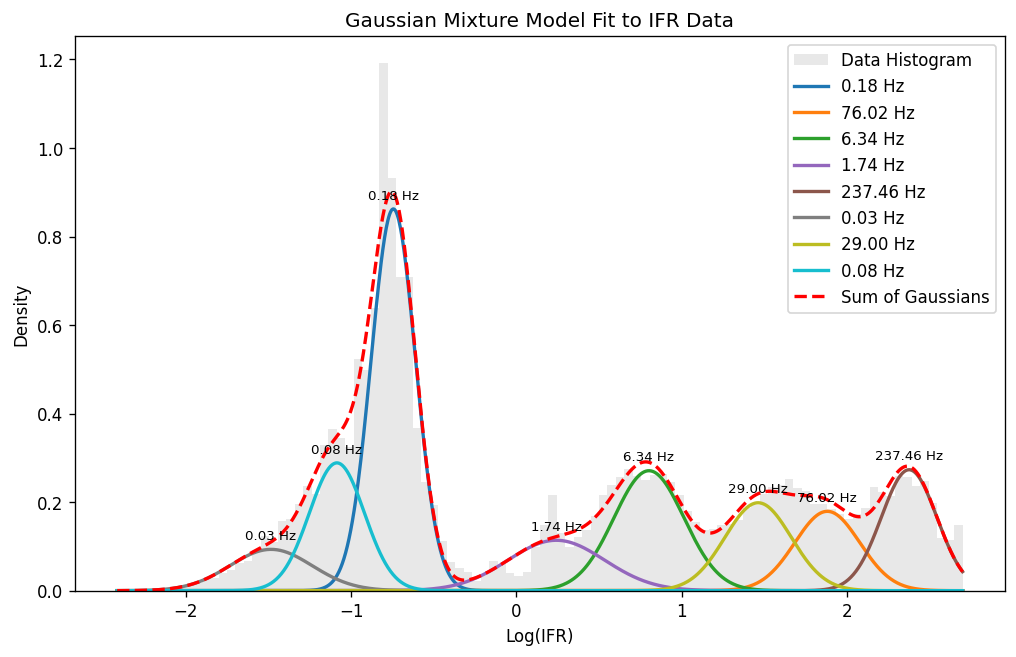

In [32]:
ifr_analyzer.plot_histogram()

[(<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well0 DIV21: Log Instantaneous Firing Rate Across Top 975 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Instantaneous Firing Rate (Hz)', ylabel='Frequency'>)),
 (<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well1 DIV21: Log Instantaneous Firing Rate Across Top 953 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Instantaneous Firing Rate (Hz)', ylabel='Frequency'>)),
 (<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well2 DIV21: Log Instantaneous Firing Rate Across Top 851 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xl

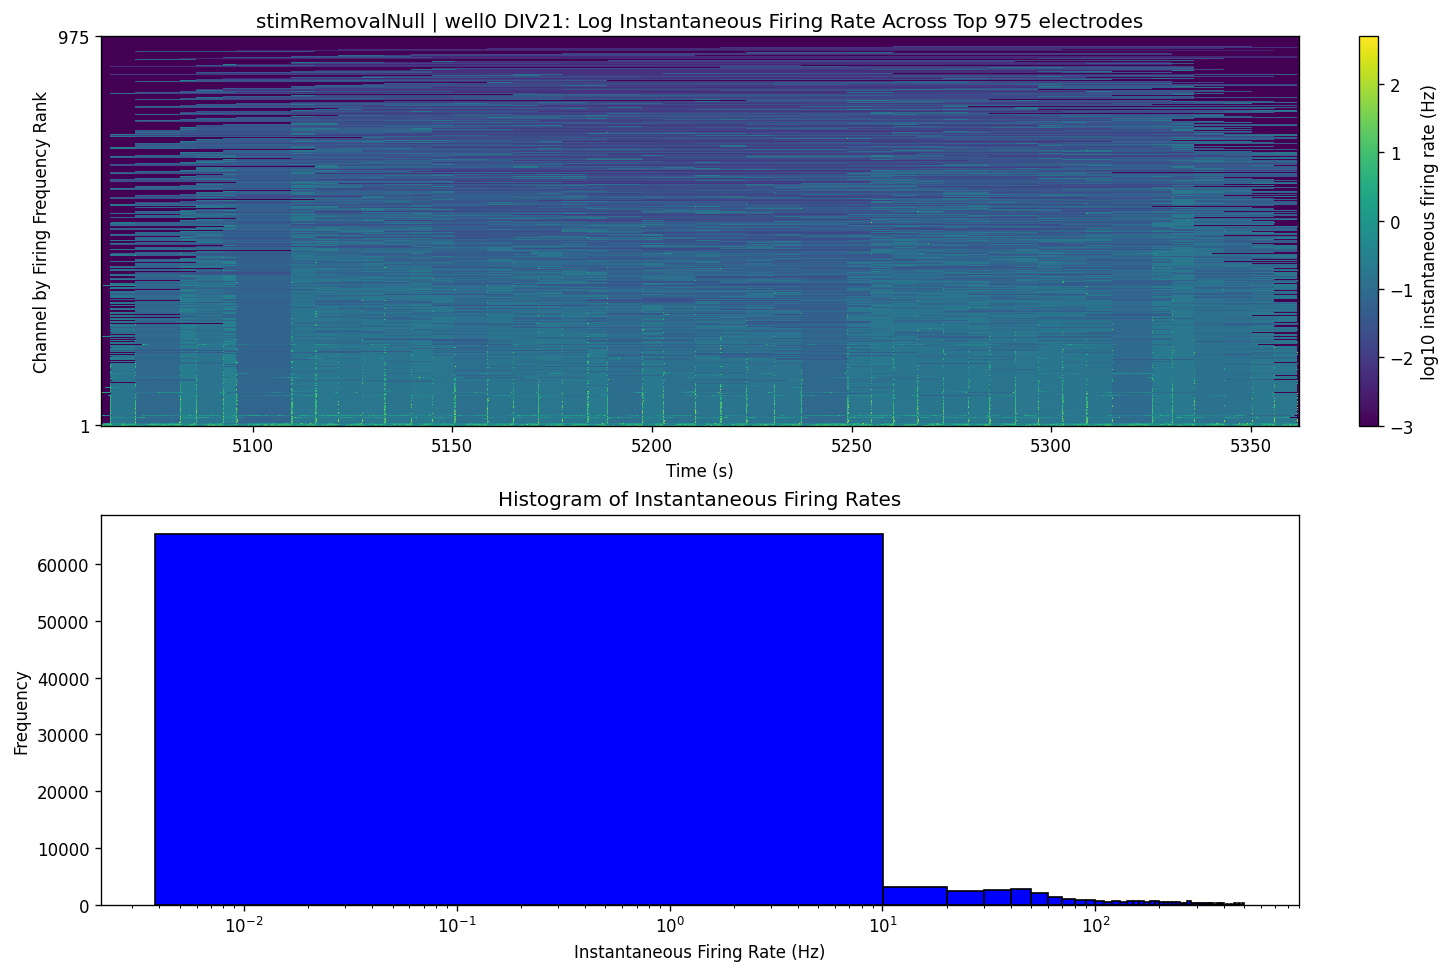

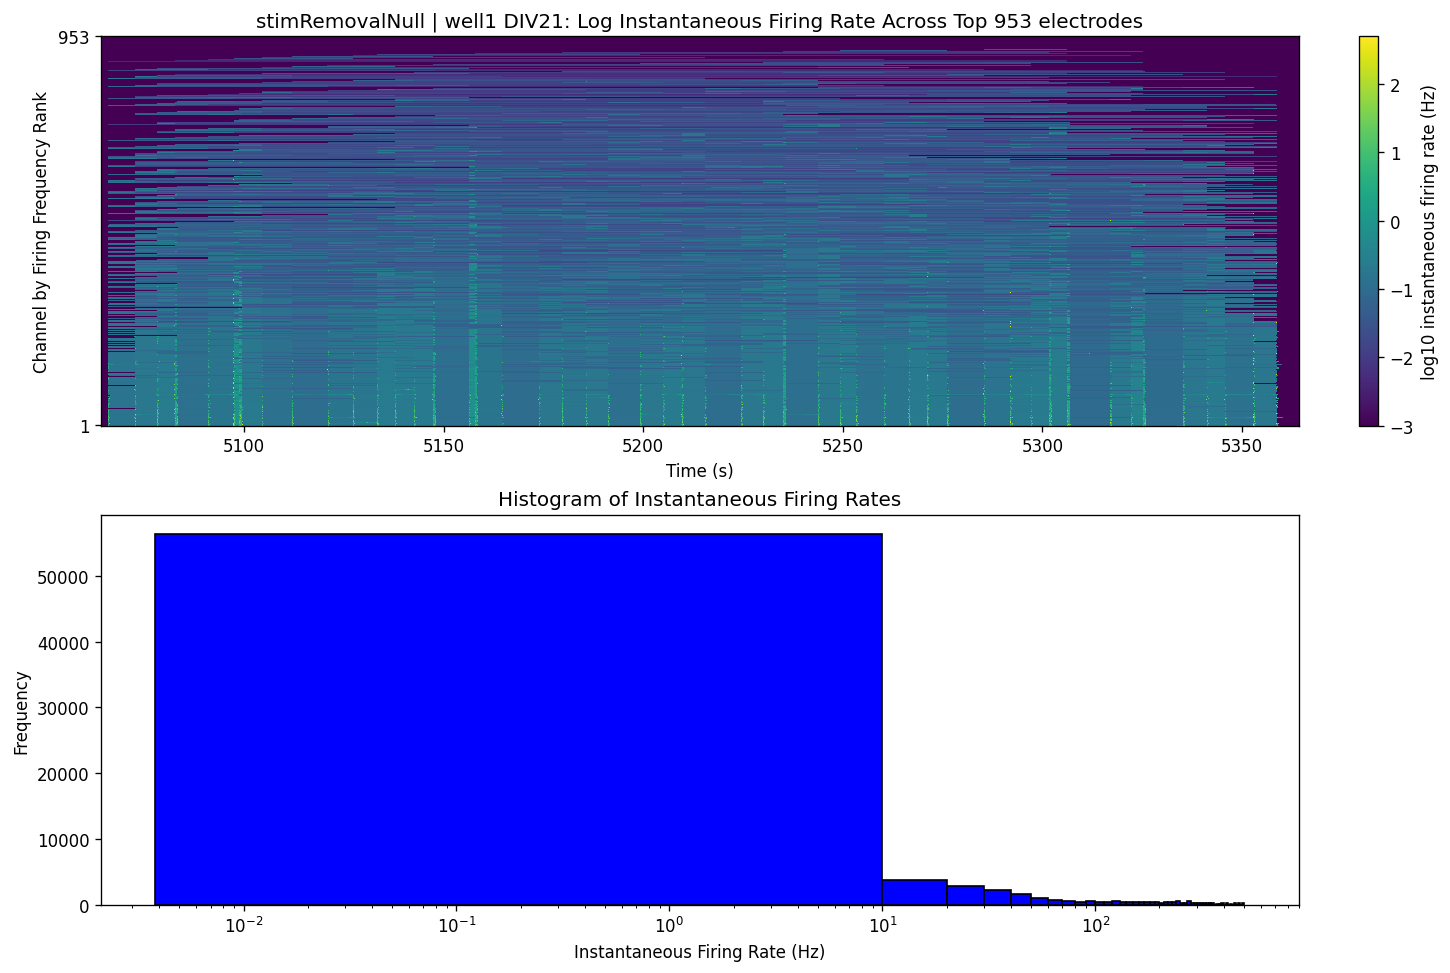

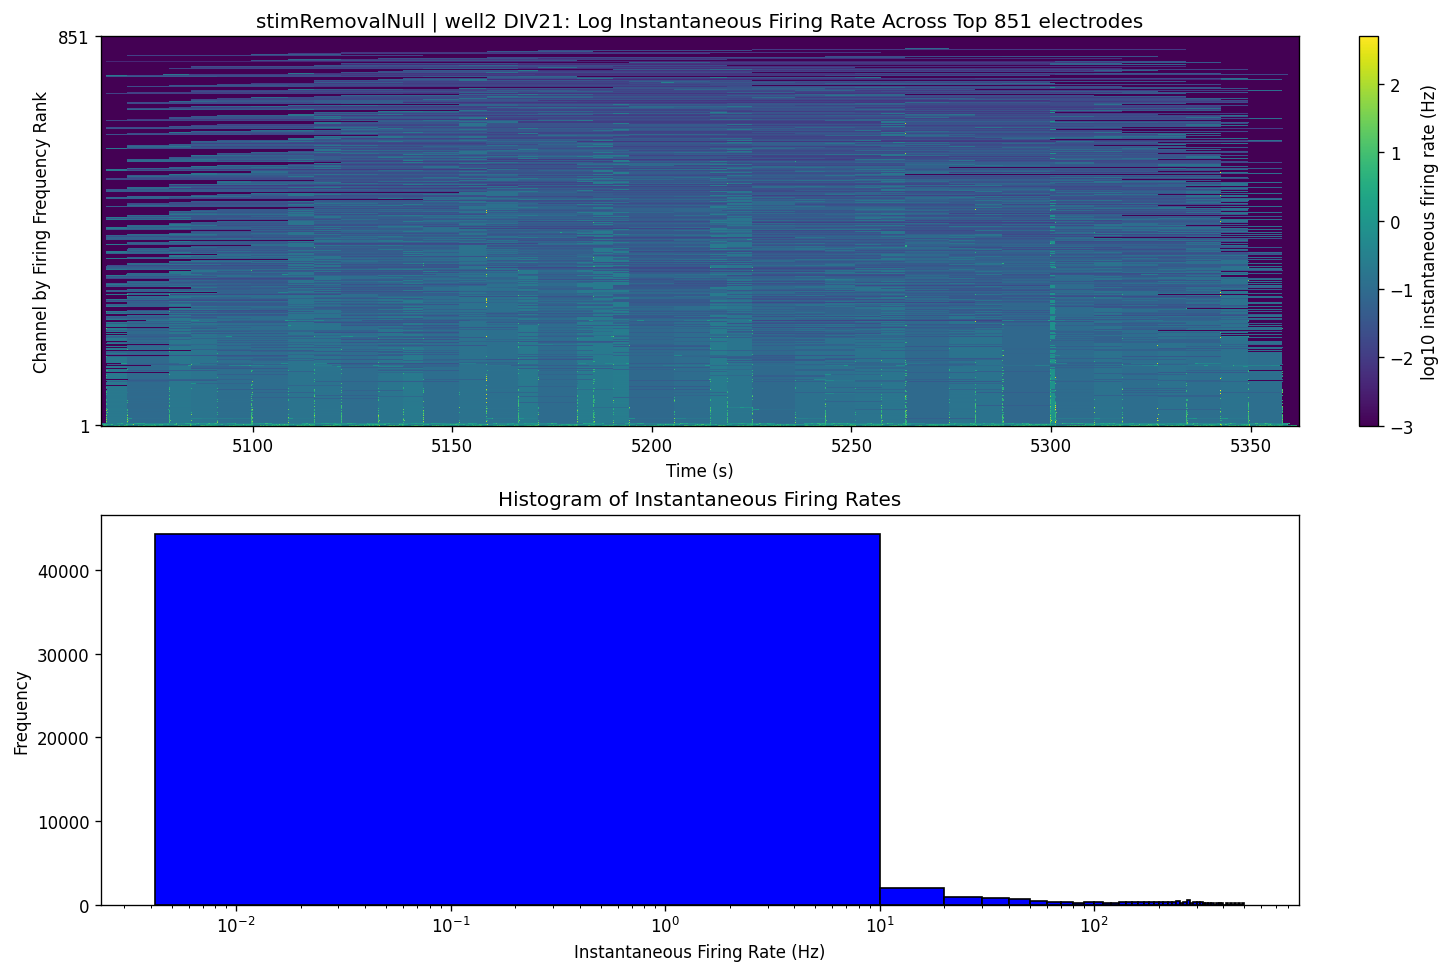

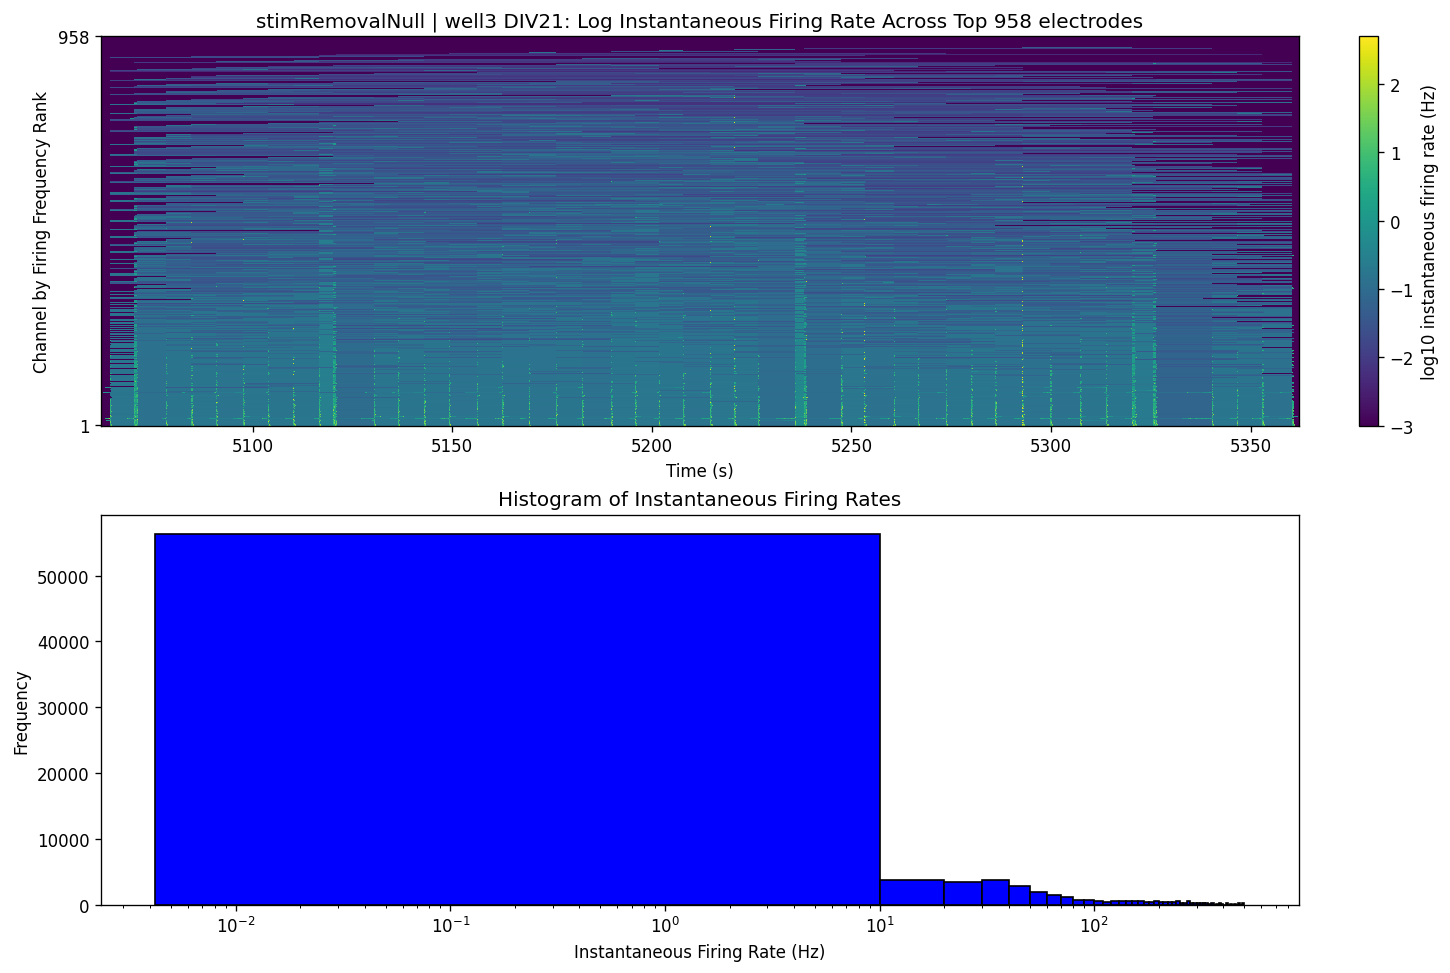

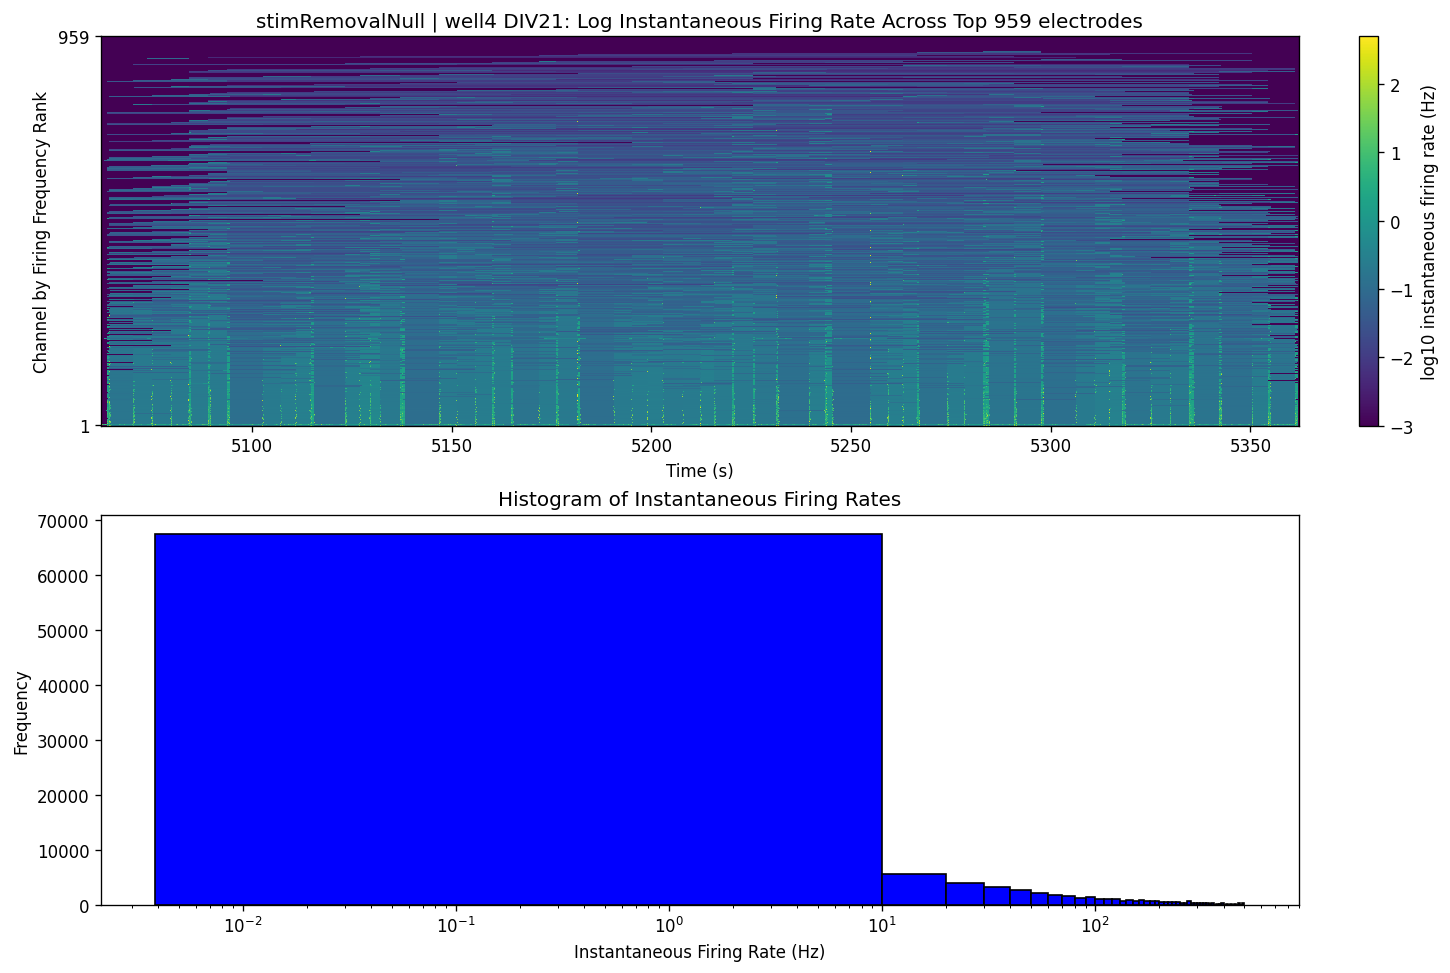

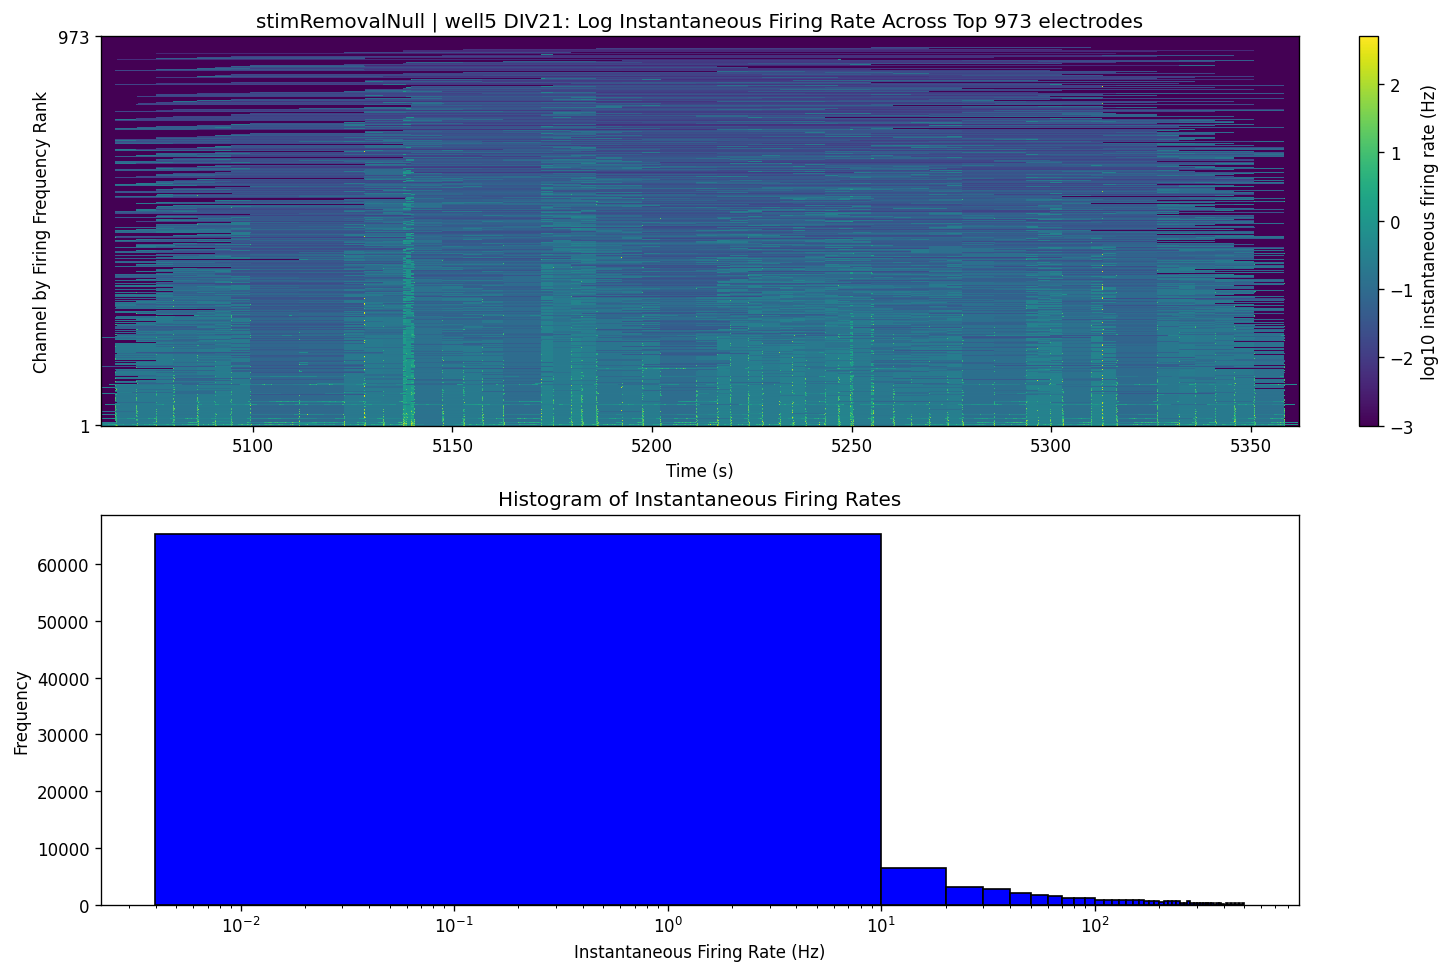

In [33]:
ifr_analyzer.plot_timeseries(title="stimRemovalNull", recording_titles=recording_labels)

## Per-Recording Distance Fits (Using Fixed Activity-State KDE Peaks)

This section fits distance-dependent firing and co-firing models to each recording independently while reusing the pooled high-activity/burst KDE peak frequencies computed above. This avoids per-recording IFR GMM peak recalculation for the synergy overlays.



=== well0 DIV21 ===
Refs: 975
Fixed activity-state KDE peaks (Hz): [ 40.23 250.67]

[Rate] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-16299.0716, BIC=-3557.4295, MI=2.15982
  Model (40.2 Hz): logL=-16765.4145, BIC=-3566.4839, MI=2.32322
[Rate] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=932.6858, p=7.700e-205
ANOVA F-statistic: 0.010239829935513596, p-value: 0.9194081648520811


/Users/danielrebbin/Documents/GitHub/ephax/ephax/analyzers/firing_distance.py:144: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_popt, _ = curve_fit(_exp_fun, x_valid, y_valid, p0=[A0, k0, C0], maxfev=10000)



[Cofiring] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-18457.5832, BIC=-4209.9118, MI=2.18691
  Model (40.2 Hz): logL=-18937.8761, BIC=-4219.3993, MI=2.31608
[Cofiring] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=960.5858, p=6.632e-211
ANOVA F-statistic: 0.022281583211728406, p-value: 0.8813555183484194

=== well1 DIV21 ===
Refs: 953
Fixed activity-state KDE peaks (Hz): [ 40.23 250.67]

[Rate] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-53347.7485, BIC=-3800.2278, MI=2.12173
  Model (40.2 Hz): logL=-55574.6902, BIC=-3809.1308, MI=2.20651
[Rate] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=4453.8834, p=0.000e+00
ANOVA F-statistic: 0.03925336796621258, p-value: 0.8429677123592885


/Users/danielrebbin/Documents/GitHub/ephax/ephax/analyzers/firing_distance.py:144: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_popt, _ = curve_fit(_exp_fun, x_valid, y_valid, p0=[A0, k0, C0], maxfev=10000)



[Cofiring] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-10047.2107, BIC=-4815.2854, MI=1.81019
  Model (40.2 Hz): logL=-10195.5093, BIC=-4825.4471, MI=1.94960
[Cofiring] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=296.5971, p=1.816e-66
ANOVA F-statistic: 0.02485727922029145, p-value: 0.874739144286789

=== well2 DIV21 ===
Refs: 851
Fixed activity-state KDE peaks (Hz): [ 40.23 250.67]

[Rate] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-30261.6203, BIC=-4213.5733, MI=1.57053
  Model (40.2 Hz): logL=-30312.9425, BIC=-4222.5478, MI=1.66789
[Rate] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=102.6443, p=4.011e-24
ANOVA F-statistic: 0.0344844260463911, p-value: 0.8526990130448452

[Cofiring] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-16824.2142, BIC=-4346.1155, MI=1.39557
  Model (40.2 Hz): logL=-17205.3411, BIC=-4355.7142, MI=1.40896
[Cofiring] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=762.2538, p=8.690e-1

...


[Cofiring] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-4875.5597, BIC=-5070.5247, MI=2.59693
  Model (40.2 Hz): logL=-4883.0423, BIC=-5080.7331, MI=2.74336
[Cofiring] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=14.9652, p=1.095e-04
ANOVA F-statistic: 0.019078697157891126, p-value: 0.890155027289231

=== well5 DIV21 ===
Refs: 973
Fixed activity-state KDE peaks (Hz): [ 40.23 250.67]

[Rate] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-6304.8516, BIC=-3090.1152, MI=2.34414
  Model (40.2 Hz): logL=-6360.4791, BIC=-3098.6703, MI=2.41172
[Rate] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=111.2550, p=5.203e-26
ANOVA F-statistic: 0.0027954699266339337, p-value: 0.9578390171711578


/Users/danielrebbin/Documents/GitHub/ephax/ephax/analyzers/firing_distance.py:144: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_popt, _ = curve_fit(_exp_fun, x_valid, y_valid, p0=[A0, k0, C0], maxfev=10000)



[Cofiring] Synergy model summary:
  Model (40.2, 250.7 Hz): logL=-4319.5088, BIC=-4736.2126, MI=2.30694
  Model (40.2 Hz): logL=-4364.0980, BIC=-4746.3780, MI=2.47068
[Cofiring] Likelihood-ratio tests vs full model:
  Model (40.2 Hz): LRT=89.1785, p=3.607e-21
ANOVA F-statistic: 0.012348474060876689, p-value: 0.911529425909463


,recording_idx,recording_id,culture_id,well,div,n_activity_ifr_frequencies,n_refs,activity_ifr_frequencies_hz,n_rate_bins,n_cofiring_bins
0,0,stimRemovalNull_well0_DIV21,stimRemovalNull_well0,0,21,2,975,"[40.233, 250.671]",73,73
1,1,stimRemovalNull_well1_DIV21,stimRemovalNull_well1,1,21,2,953,"[40.233, 250.671]",73,73
2,2,stimRemovalNull_well2_DIV21,stimRemovalNull_well2,2,21,2,851,"[40.233, 250.671]",73,73
3,3,stimRemovalNull_well3_DIV21,stimRemovalNull_well3,3,21,2,958,"[40.233, 250.671]",73,73
4,4,stimRemovalNull_well4_DIV21,stimRemovalNull_well4,4,21,2,959,"[40.233, 250.671]",73,73
5,5,stimRemovalNull_well5_DIV21,stimRemovalNull_well5,5,21,2,973,"[40.233, 250.671]",73,73


,div,n_recordings,n_wells,mean_activity_ifr_frequencies,mean_refs,mean_rate_bins,mean_cofiring_bins
0,21,6,6,2.0,944.833,73.0,73.0


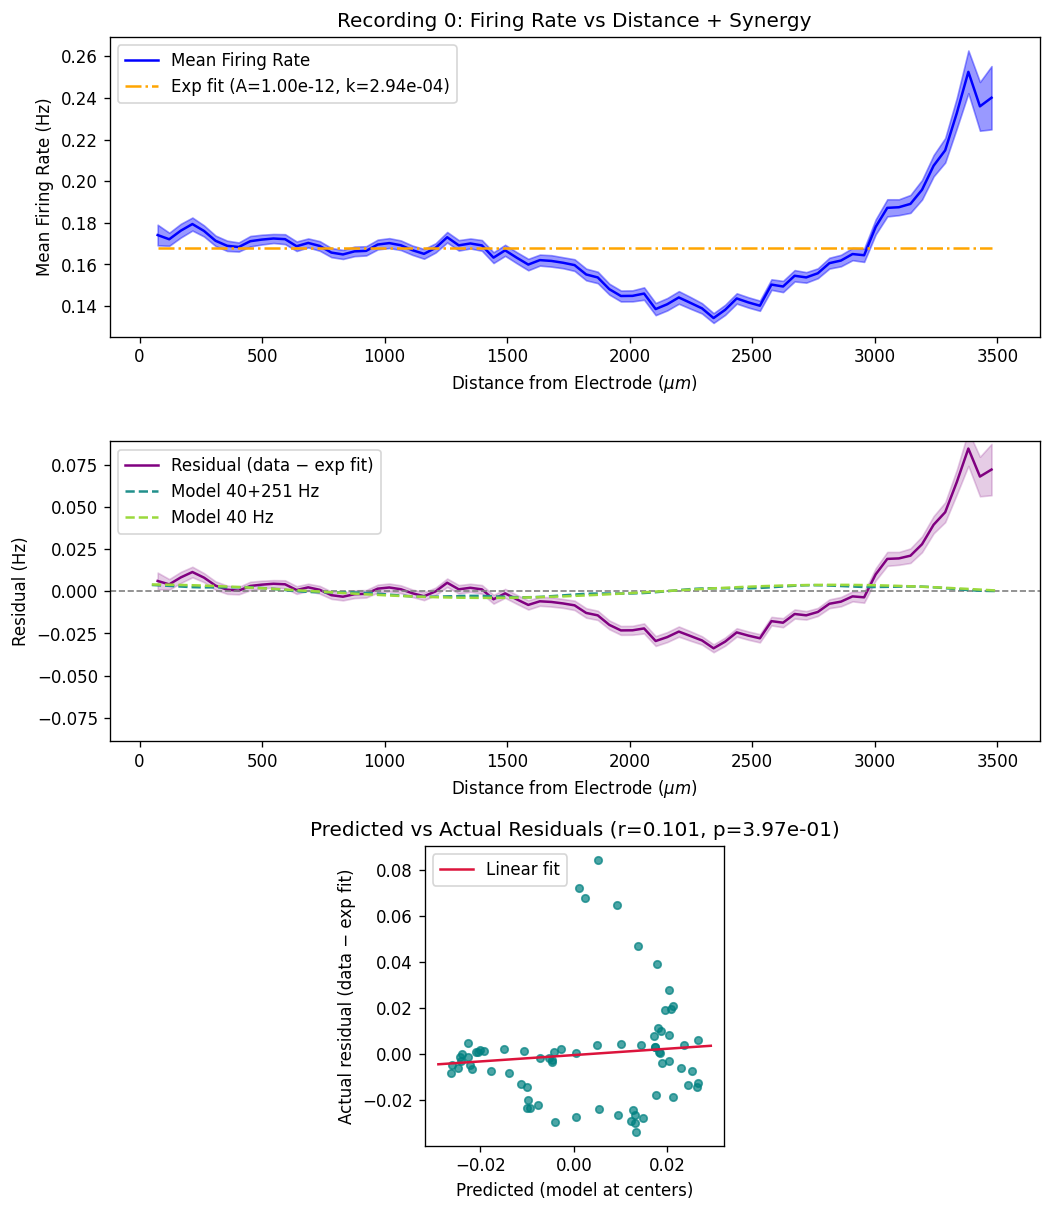

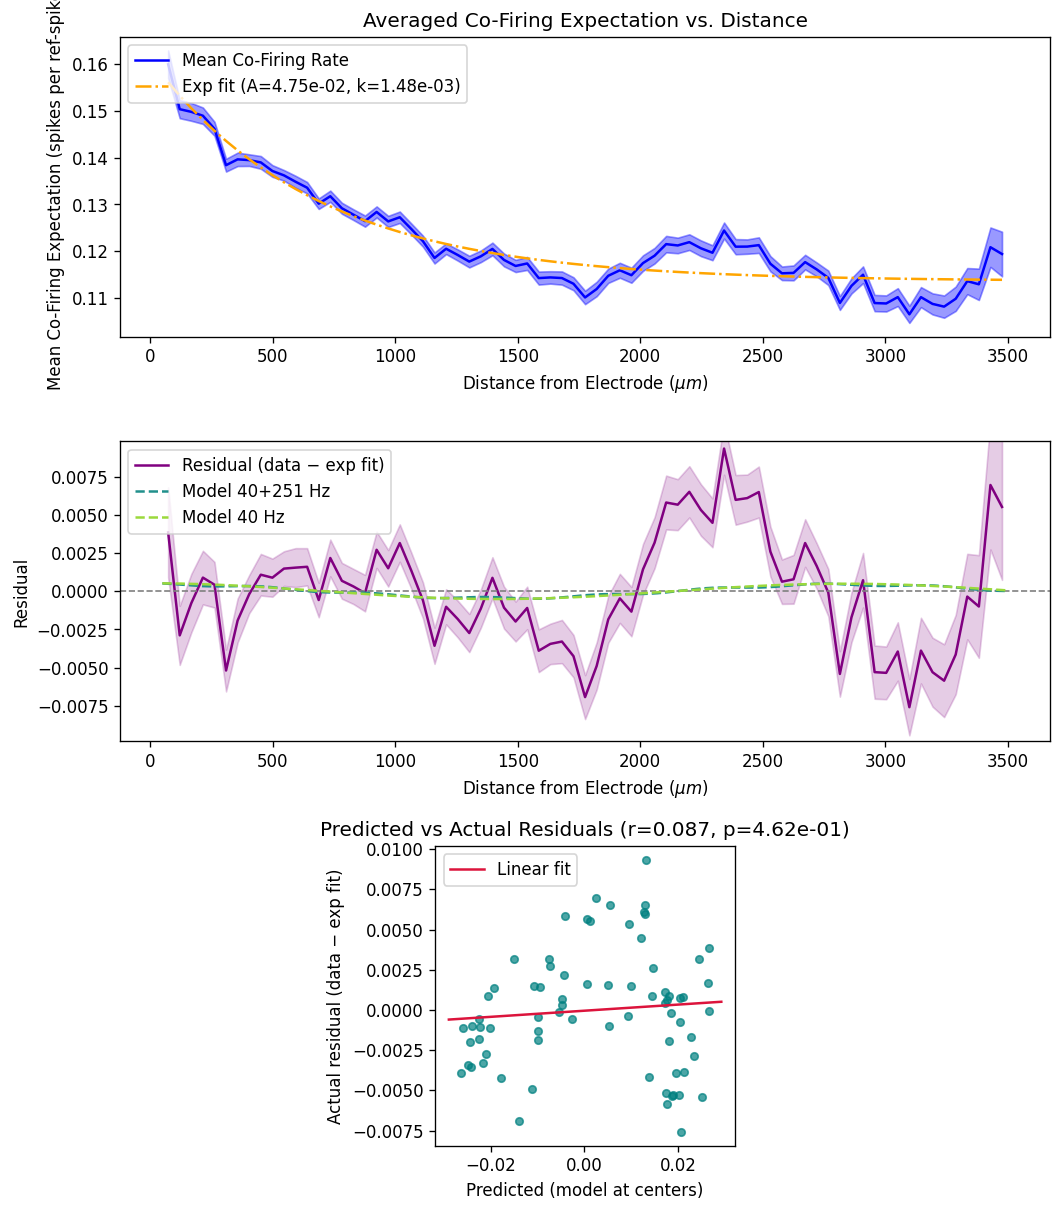

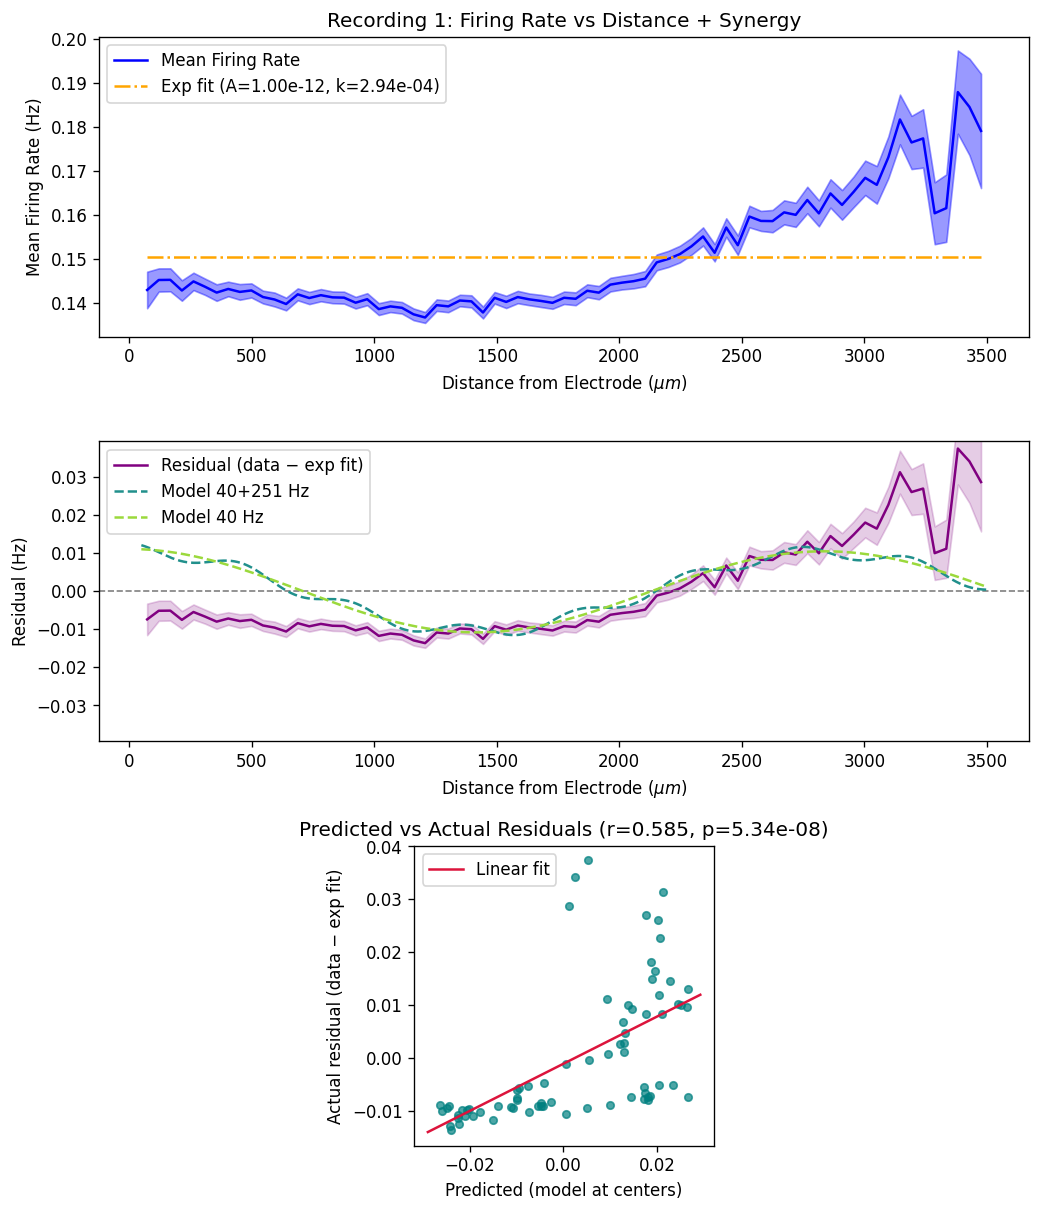

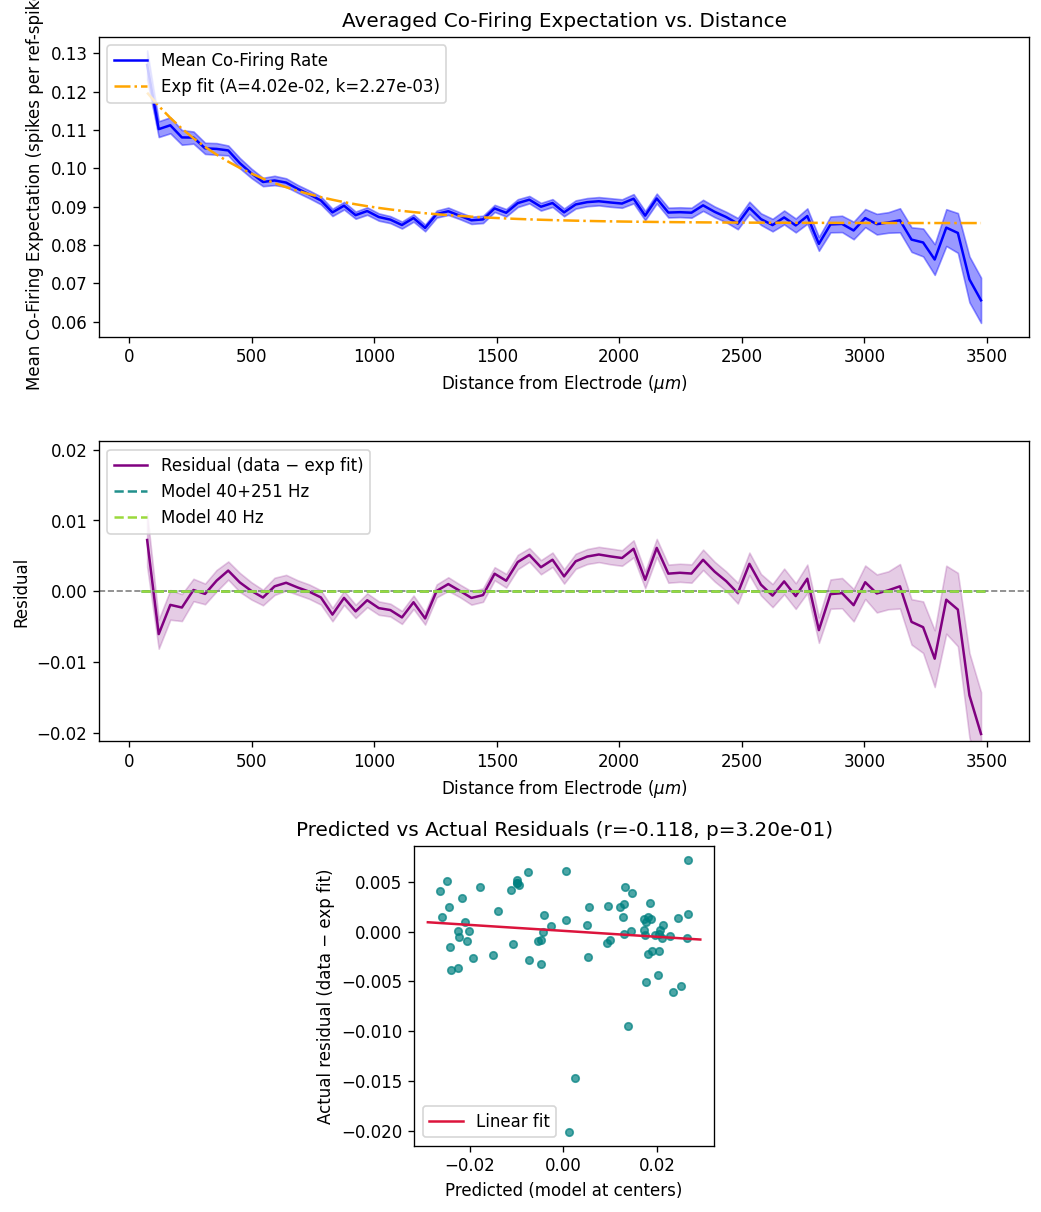

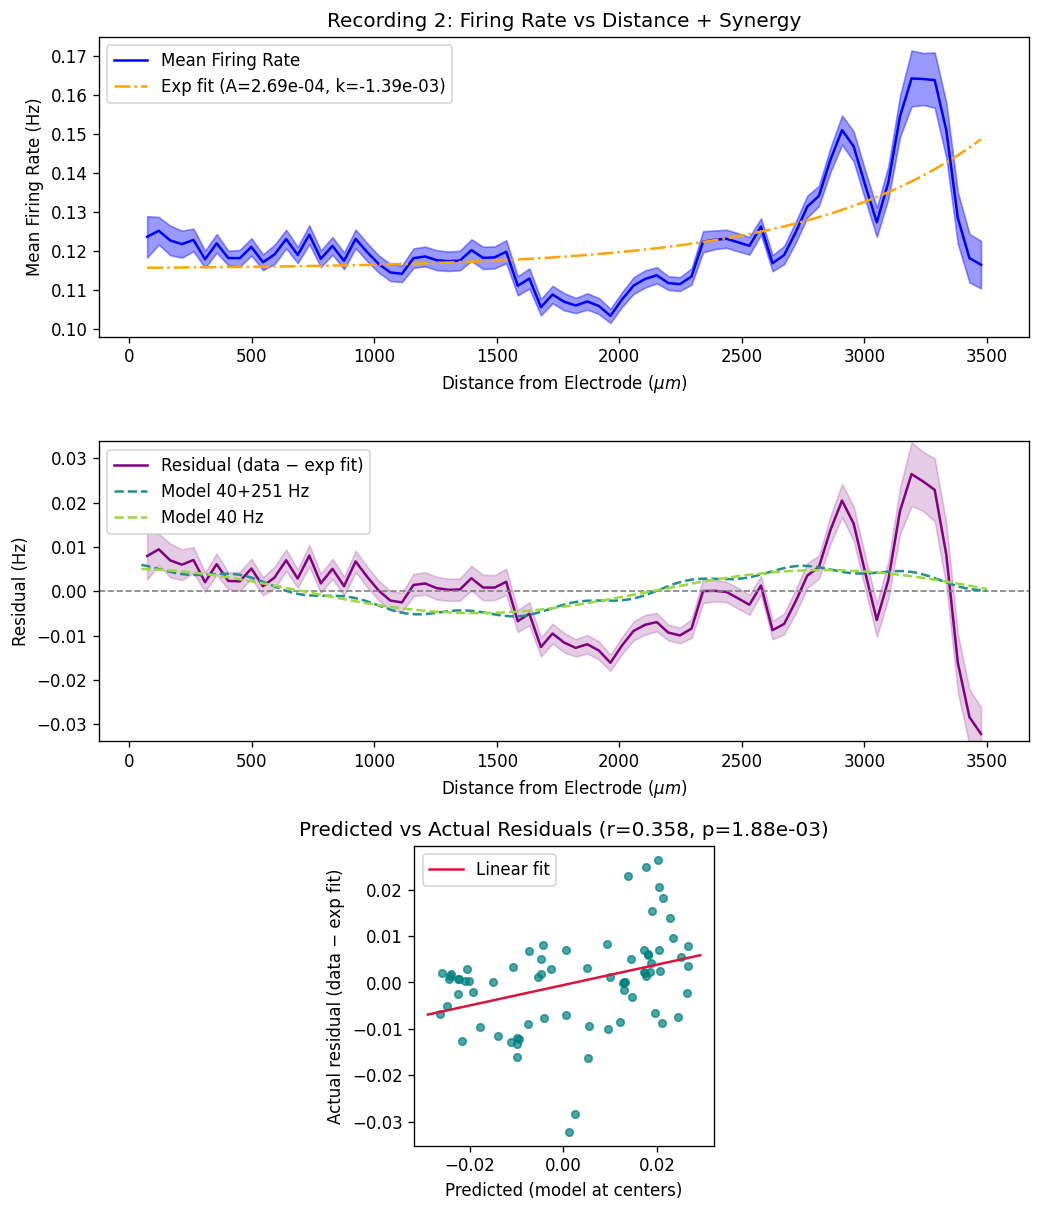

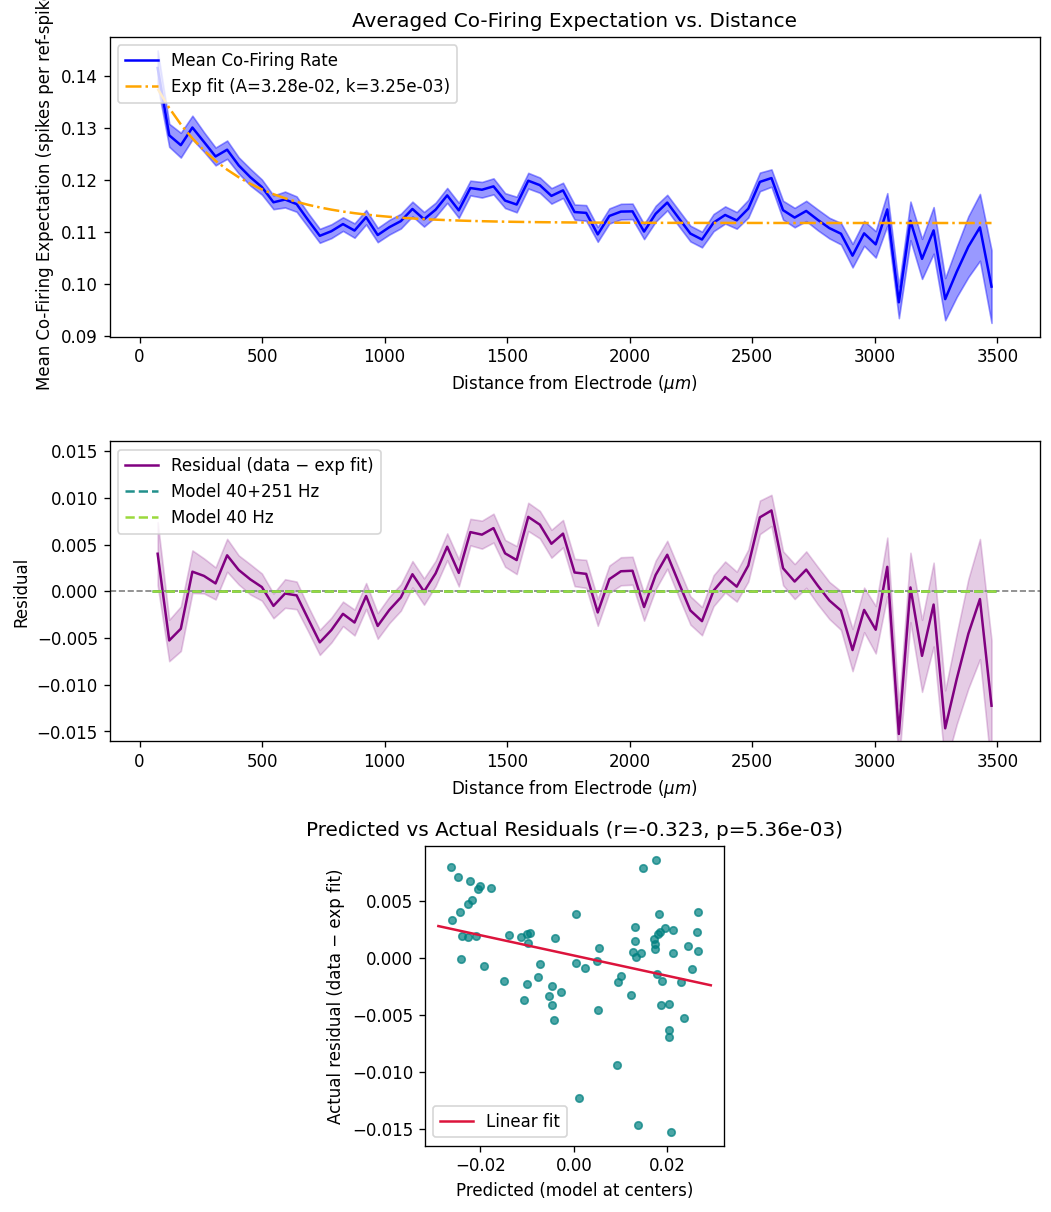

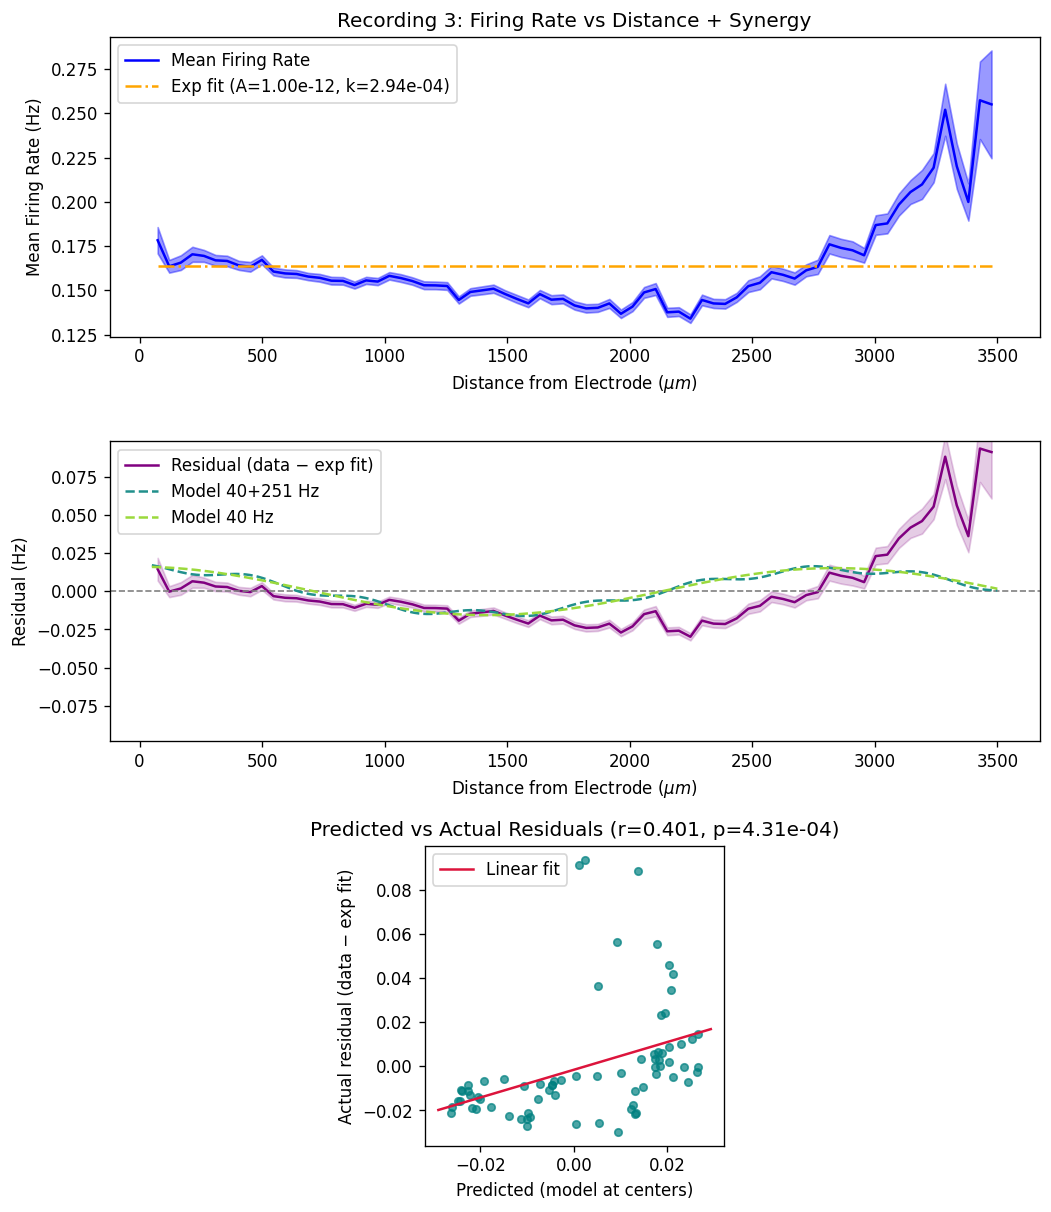

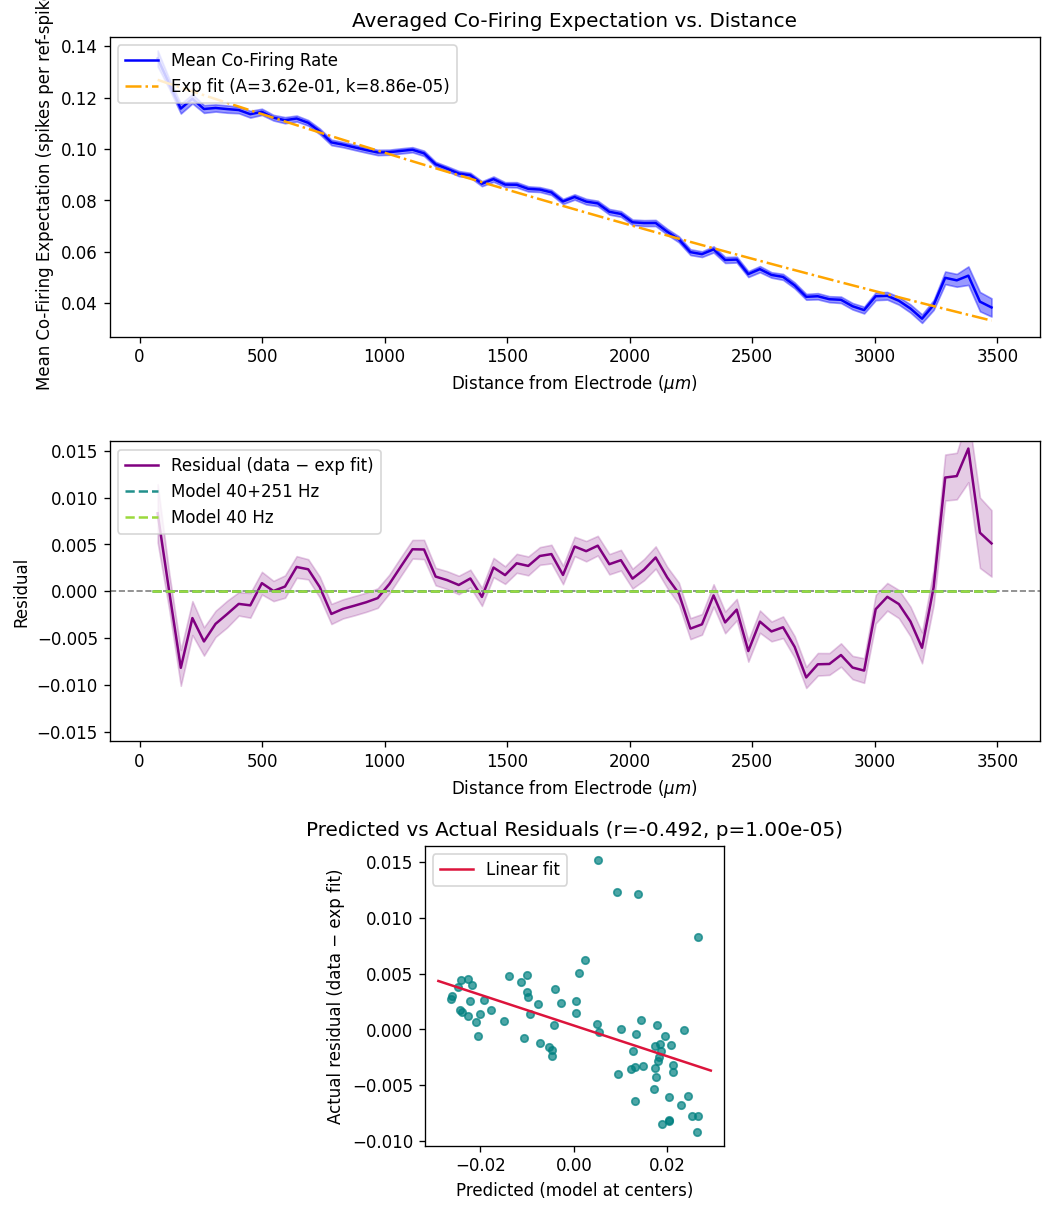

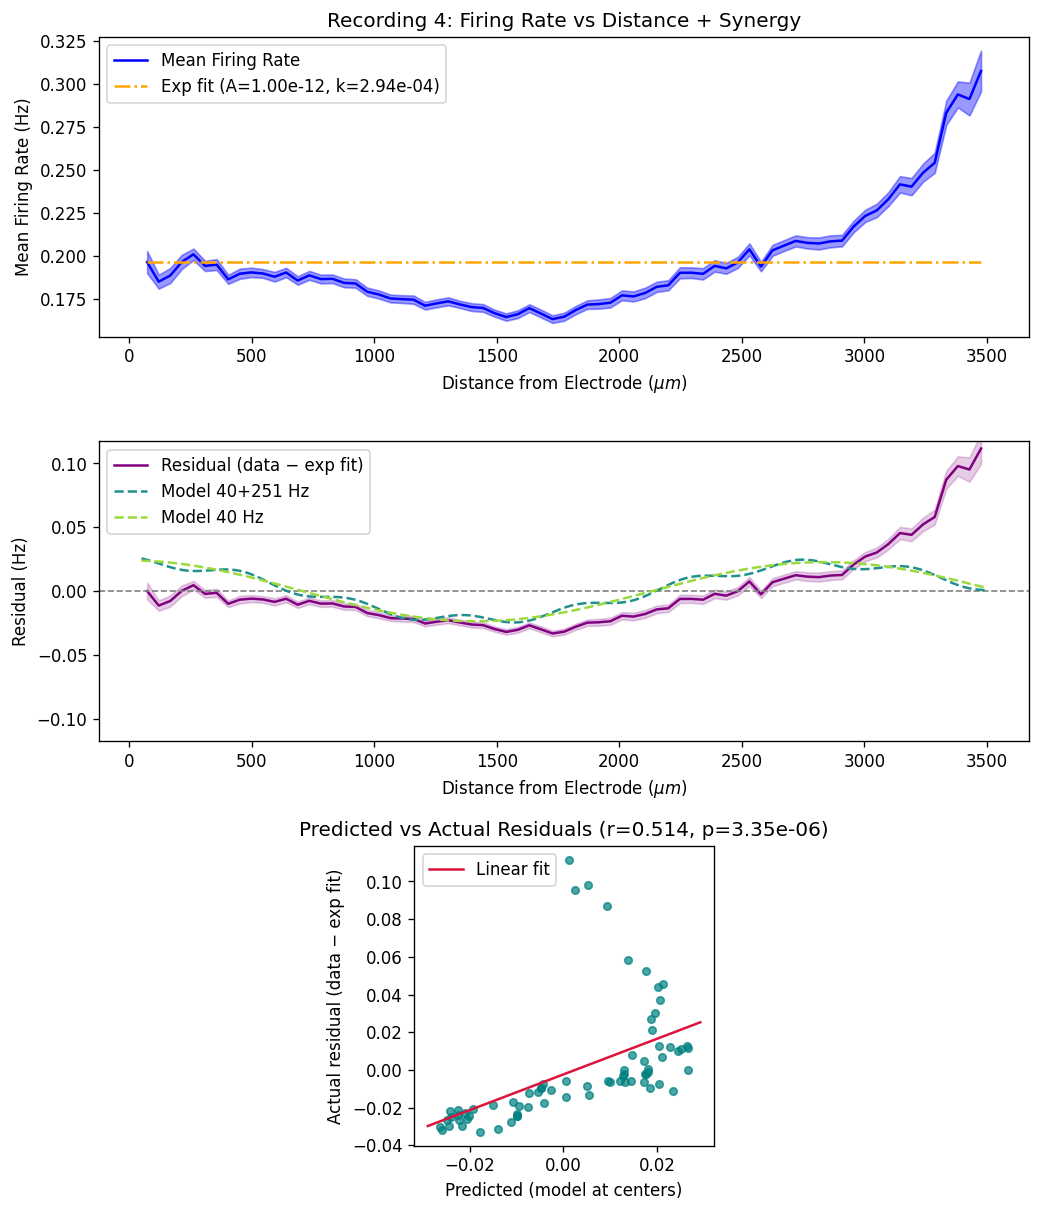

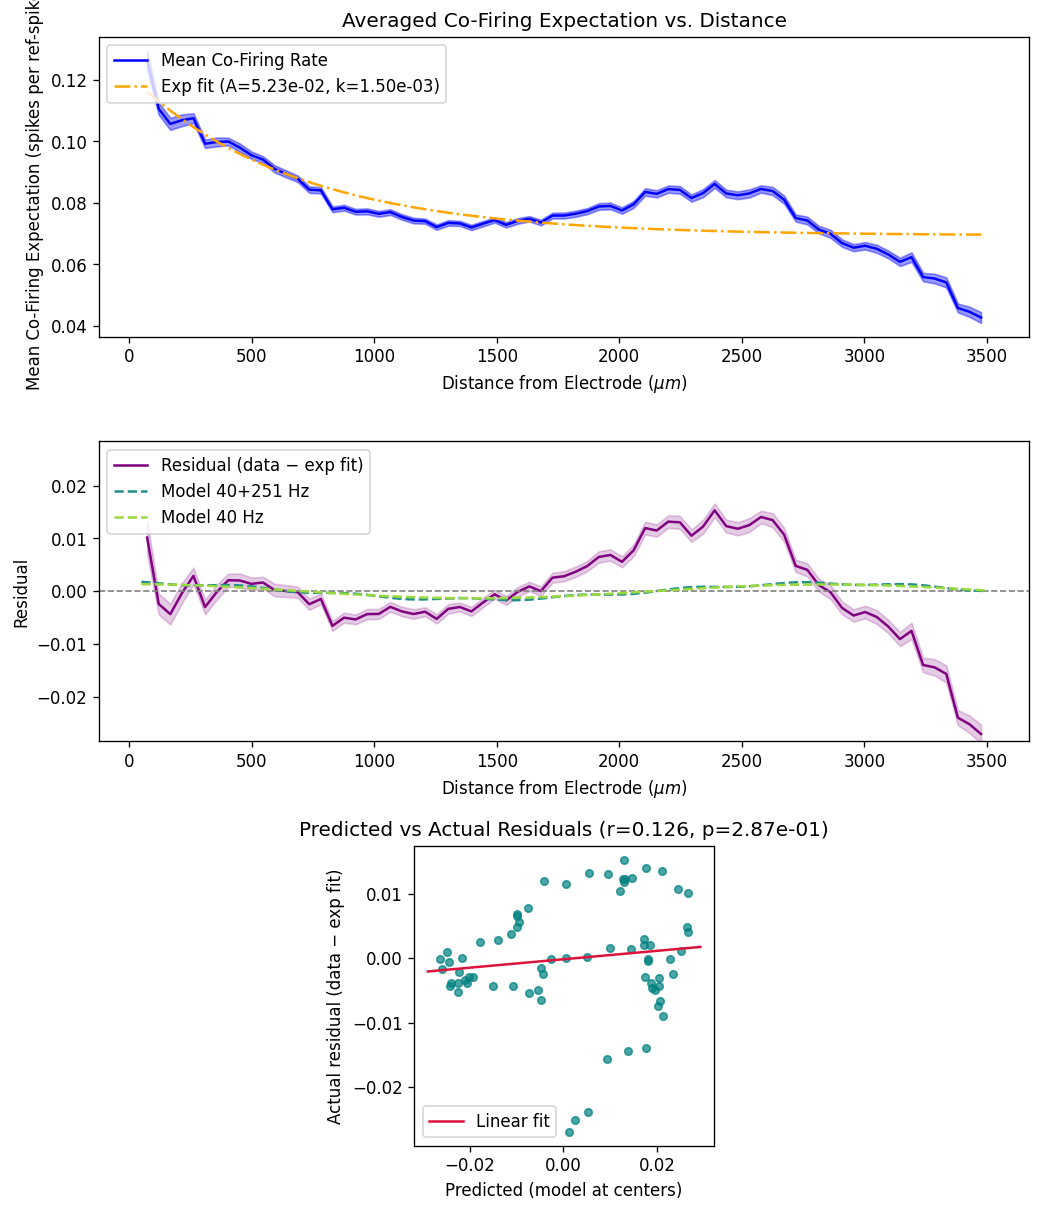

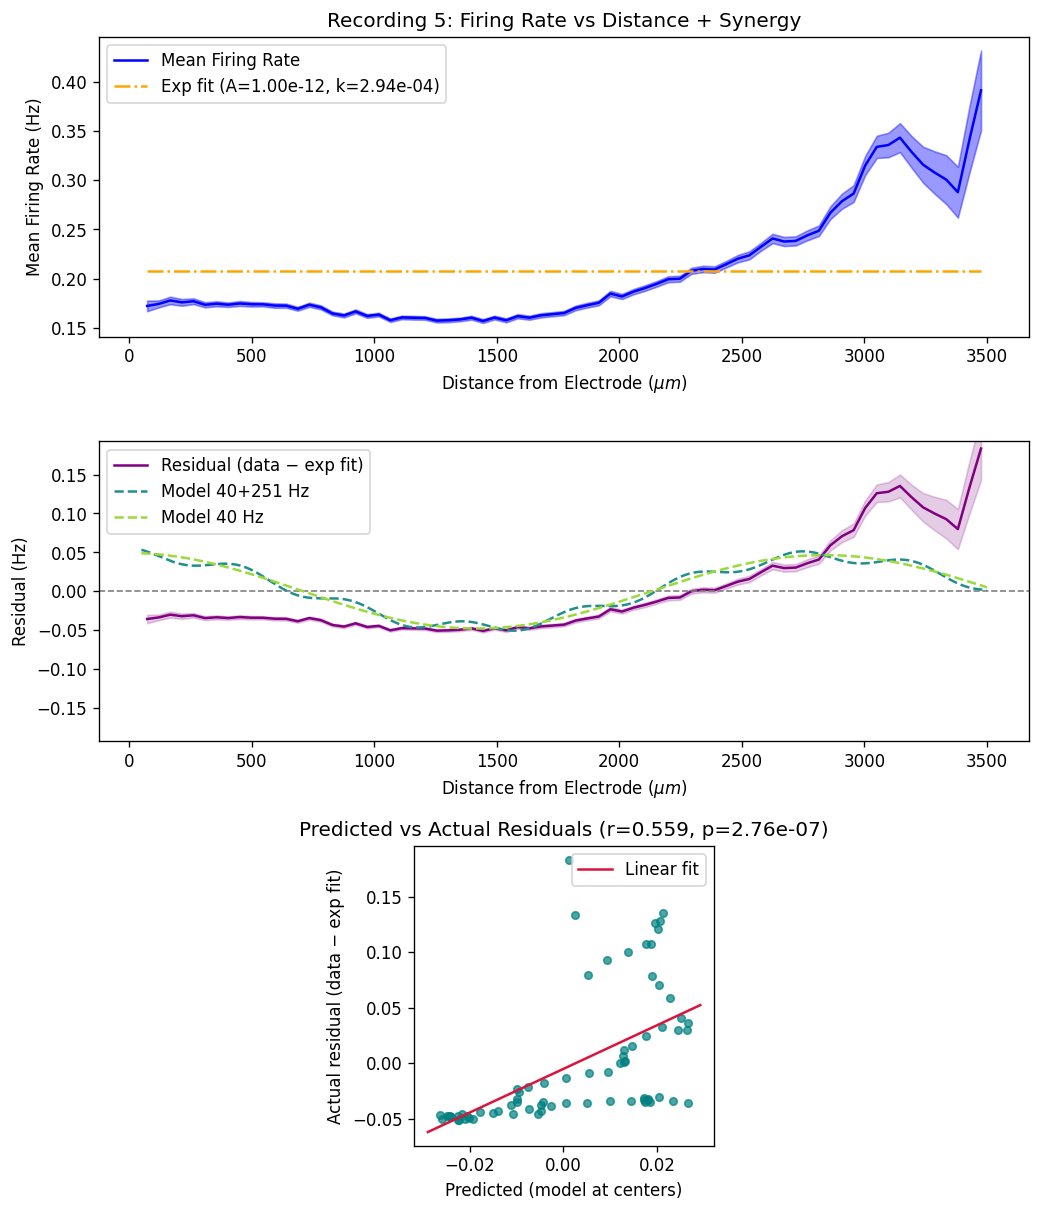

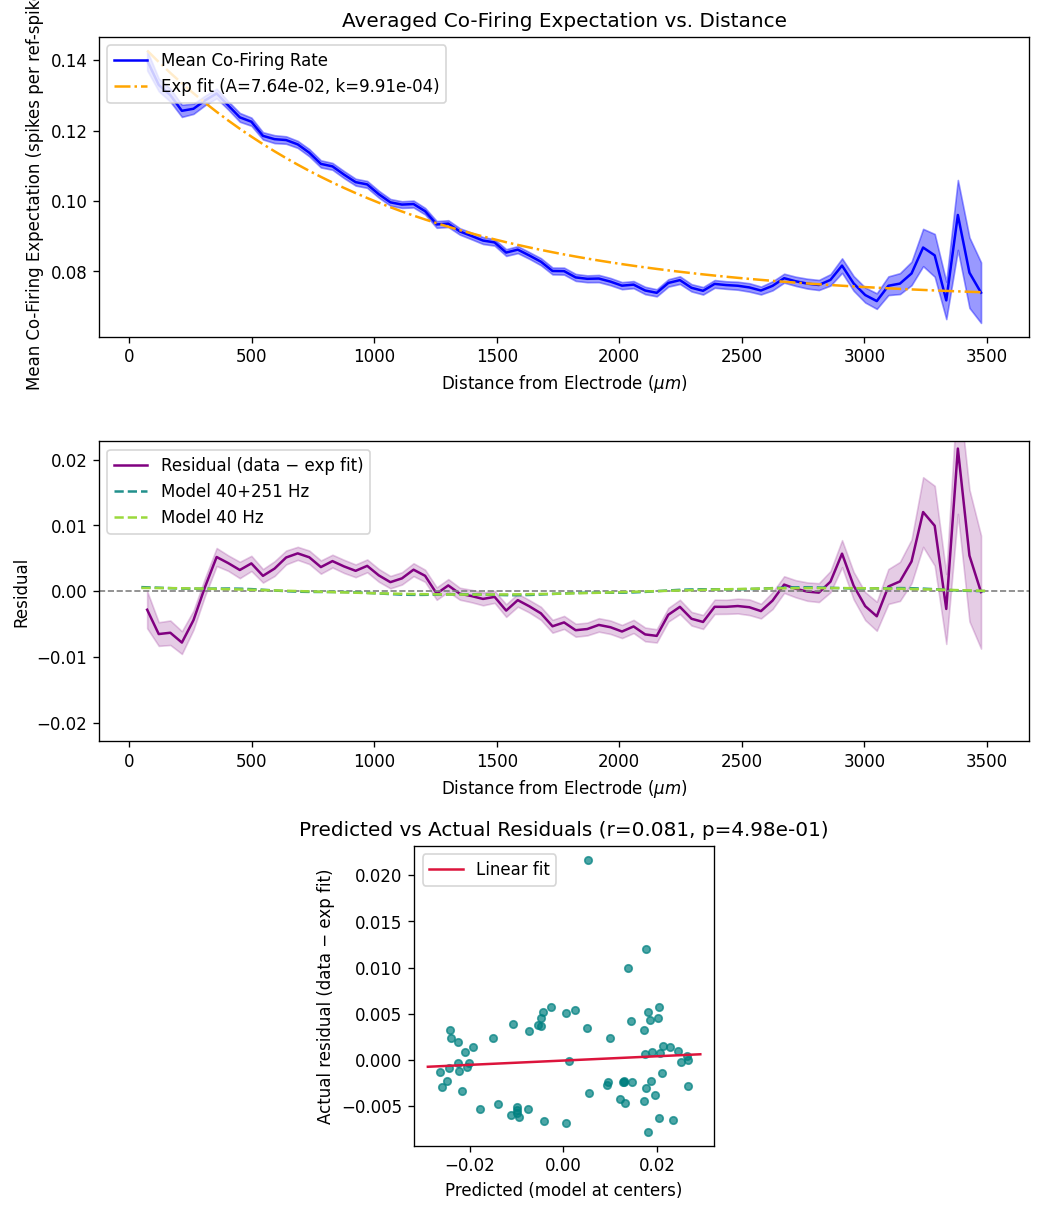

In [34]:
from ephax import RestingActivityDataset

COFIRING_PM_MS = 2.0
per_recording_rows = []

for rec_idx, rec in enumerate(ds.recordings):
    meta = recording_metadata[rec_idx]
    print(f"\n=== {recording_labels[rec_idx]} ===")
    ds_i = RestingActivityDataset(recordings=[rec], sf=ds.sf)

    # Keep the same selection strategy as the pooled analysis
    refs_i = ds_i.select_ref_electrodes(prep_cfg)
    n_refs = int(refs_i[0].size) if refs_i and hasattr(refs_i[0], 'size') else 0

    print(f"Refs: {n_refs}")
    print("Fixed activity-state KDE peaks (Hz):", np.round(activity_ifr_frequency_values_hz, 2))

    # Distance-dependent firing fit for this recording
    fd_i = FiringDistanceAnalyzer(
        ds_i,
        selection_prep_config=prep_cfg,
        ifr_config=ifr_cfg,
        v_eph=V_AX,
        v_ax=V_EPH,
        frequency_values_hz=activity_ifr_frequency_values_hz,
    )

    rate_i = fd_i.avg_rate_vs_distance()
    n_rate_bins = int(rate_i.binned.centers.size)
    if n_rate_bins == 0:
        print("No valid rate-vs-distance bins for this recording; skipping rate plot.")
    else:
        fd_i.plot_rate_with_synergy(
            rate_i,
            title=f"Recording {rec_idx}: Firing Rate vs Distance + Synergy",
            show_exponential_fit=True,
        )

    # Distance-dependent co-firing fit for this recording
    cof_i = fd_i.cofiring_avg_vs_distance(plusminus_ms=COFIRING_PM_MS, log=False)
    n_cof_bins = int(cof_i.binned.centers.size)
    if n_cof_bins == 0:
        print("No valid cofiring-vs-distance bins for this recording; skipping cofiring plot.")
    else:
        fd_i.plot_cofiring_with_synergy(
            cof_i,
            show_exponential_fit=True,
        )

    per_recording_rows.append(
        {
            'recording_idx': rec_idx,
            'recording_id': meta['recording_id'],
            'culture_id': meta['culture_id'],
            'well': int(meta['well']),
            'div': int(meta['div']),
            'n_activity_ifr_frequencies': int(activity_ifr_frequency_values_hz.size),
            'n_refs': n_refs,
            'activity_ifr_frequencies_hz': np.round(activity_ifr_frequency_values_hz, 3).tolist(),
            'n_rate_bins': n_rate_bins,
            'n_cofiring_bins': n_cof_bins,
        }
    )

per_recording_summary = pd.DataFrame(per_recording_rows)
aggregate_fit_summary = (
    per_recording_summary
    .groupby("div", as_index=False)
    .agg(
        n_recordings=("recording_idx", "count"),
        n_wells=("well", "nunique"),
        mean_activity_ifr_frequencies=("n_activity_ifr_frequencies", "mean"),
        mean_refs=("n_refs", "mean"),
        mean_rate_bins=("n_rate_bins", "mean"),
        mean_cofiring_bins=("n_cofiring_bins", "mean"),
    )
)
display(per_recording_summary)
display(aggregate_fit_summary.round(3))


## Distance-Dependent Firing Statistics

In [ ]:
shuffle_layout_coordinates = True
permute_for_null = True
num_permutations = 2
perm_seed = 12345

perm_datasets = []
if permute_for_null:
    for perm_idx in range(num_permutations):
        permuted_recs = []
        for rec_idx, rec in enumerate(ds.recordings):
            seed = None if perm_seed is None else perm_seed + perm_idx * 1000 + rec_idx
            permuted_recs.append(
                rec.randomize_electrode_mapping(
                    seed=seed,
                    inplace=False,
                    shuffle_layout_coordinates=shuffle_layout_coordinates,
                )
            )
        perm_datasets.append(RestingActivityDataset(recordings=permuted_recs, sf=ds.sf))

fd_perm_dataset = perm_datasets[0] if perm_datasets else None
fd_analyzer = FiringDistanceAnalyzer(
    ds,
    dataset_perm=fd_perm_dataset,
    selection_prep_config=prep_cfg,
    ifr_config=ifr_cfg,
    v_eph=V_EPH,
    v_ax=V_AX,
    frequency_values_hz=activity_ifr_frequency_values_hz,
)

plusminus_ms = 2.0
rate_vs_distance = fd_analyzer.avg_rate_vs_distance()
fd_analyzer.plot_rate_with_synergy(rate_vs_distance, show_exponential_fit=True)

cof_res = fd_analyzer.cofiring_avg_vs_distance(plusminus_ms=plusminus_ms, log=False)
fd_analyzer.plot_cofiring_with_synergy(cof_res)

distance_hist_distances, distance_hist_weights = fd_analyzer.distance_histogram(
    finite_size_correction=True,
    min_distance=50,
    max_distance=3500,
)
fd_analyzer.plot_distance_hist_with_synergy(
    distance_hist_distances,
    distance_hist_weights,
    allow_offset=True,
)


## Temporal Co-firing Heatmap

In [36]:
cft_cfg = CofiringTemporalConfig(start_ms=-20, stop_ms=20, step_ms=1, normalize=False)
cft_analyzer = CofiringTemporalAnalyzer(ds, cft_cfg, selection_prep_config=prep_cfg)
cft_analyzer.plot_avg_cofiring_heatmap()


KeyboardInterrupt: 

## Optional: Co-firing GIF

This can be slow on larger datasets.


In [ ]:
cfcfg = CofiringTemporalConfig(start_ms=-20, stop_ms=20, step_ms=4, normalize=False)
cfa = CofiringTemporalAnalyzer(ds, cfcfg, selection_prep_config=prep_cfg)

# cfa.plot_avg_cofiring_heatmap()
# cfa.create_theta_gif(output_filename="cofiring_theta_stimRemovalNull.gif")
cfa.create_grid_gif(output_filename="cofiring_grid_stimRemovalNull.gif")
display(Image(filename="cofiring_grid_stimRemovalNull.gif"))


## DCT Spatial Analysis

In [ ]:
dct_an = DCTAnalyzer(ds)
interp_grids = dct_an.compute_interpolated_grids(grid_size=50.0)

avg_dct = DCTAnalyzer.average_dct([g.grid for g in interp_grids])
recon = DCTAnalyzer.reconstruct_from_top_components(
    avg_dct,
    stop_rank=3,
    start_rank=0,
    plot_distribution=True,
)
DCTAnalyzer.plot_reconstructed_grid(reconstructed=recon, res=interp_grids[0])
DCTAnalyzer.extract_and_plot_spatial_frequencies_from_dct(
    avg_dct,
    n_components_stop=3,
    n_components_start=0,
    array_dims=(3800, 2100),
    axis="x",
)
